ANOVA analysis - sensor position

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
from scipy.stats import shapiro, levene, bartlett, anderson, normaltest

import pingouin as pg
from itertools import combinations
import matplotlib.pyplot as plt

In [2]:
# normality and homogeneity of variance tests for ANOVA assumptions
def check_anova_assumptions(df, group_col, metric_col, group_order=None):
    if group_order is None:
        group_order = df[group_col].unique()

    print(f"\n=== Normality test (D’Agostino and Pearson) for {metric_col} ===")
    for group in group_order:
        data = df[df[group_col] == group][metric_col]
        stat, p = normaltest(data)
        result = "OK normal" if p > 0.05 else "not normal"
        print(f"{group.ljust(25)}:\tp = {p:.4f}\t→\t{result}")

    print(f"\n=== Normality test (Shapiro-Wilk) for {metric_col} ===")
    for group in group_order:
        data = df[df[group_col] == group][metric_col]
        stat, p = shapiro(data)
        result = "OK normal" if p > 0.05 else "not normal"
        print(f"{group.ljust(25)}:\tp = {p:.4f}\t→\t{result}")

    print(f"\n=== Normality test (Anderson-Darling) for {metric_col} ===")
    for group in group_order:
        data = df[df[group_col] == group][metric_col]
        result = anderson(data)
        stat = result.statistic
        crit_5 = result.critical_values[2]
        interpretation = "OK normal" if stat < crit_5 else "not normal"
        print(f"{group.ljust(25)}:\tA² = {stat:.4f},\t5% critical = {crit_5:.4f}\t→\t{interpretation}")

    print(f"\n=== Homogeneity of variance tests for {metric_col} ===")
    groups = [df[df[group_col] == group][metric_col] for group in group_order]

    stat_levene, p_levene = levene(*groups)
    result_levene = "OK equal variances" if p_levene > 0.05 else "unequal variances"
    print(f"Levene’s test  : p = {p_levene:.4f}\t→\t{result_levene}")

    stat_bartlett, p_bartlett = bartlett(*groups)
    result_bartlett = "OK equal variances" if p_bartlett > 0.05 else "unequal variances"
    print(f"Bartlett’s test: p = {p_bartlett:.4f}\t→\t{result_bartlett}")

    # Brown–Forsythe test (Levene with center='median')
    stat_bf, p_bf = levene(*groups, center='median')
    result_bf = "OK equal variances" if p_bf > 0.05 else "unequal variances"
    print(f"Brown–Forsythe : p = {p_bf:.4f}\t→\t{result_bf}")

In [3]:
def interpret_eta2(x: float) -> str:
    if x < 0.01:
        return "negligible"
    elif x < 0.06:
        return "small"
    elif x < 0.14:
        return "medium"
    else:
        return "large"

def interpret_d_like(x: float) -> str:
    ax = abs(x)
    if ax < 0.2:
        return "negligible"
    elif ax < 0.5:
        return "small"
    elif ax < 0.8:
        return "medium"
    else:
        return "large"

In [4]:
# ANOVA with eta squared, Games-Howell posthoc, and pairwise Hedges g effect sizes
def run_anova_full(df, group_col, metric_col, show_ci=True):
    # ===== Welch ANOVA =====
    print(f"\n=== Welch ANOVA for {metric_col} ===")
    welch = pg.welch_anova(dv=metric_col, between=group_col, data=df)
    print(welch.to_string(index=False))

    # Overall effect size (np2) interpretation
    if "np2" in welch.columns:
        np2 = float(welch.loc[0, "np2"])
        print(f"\nEffect size (partial η², np2) = {np2:.4f} → {interpret_eta2(np2)} effect")
    else:
        np2 = None
        print("\nEffect size: np2 not provided by Welch ANOVA output.")

    # ===== Games-Howell post-hoc =====
    print(f"\n=== Games-Howell post-hoc test for {metric_col} ===")
    gh = pg.pairwise_gameshowell(dv=metric_col, between=group_col, data=df).copy()
    print(gh.to_string(index=False))

    # ===== Pairwise effect sizes =====
    print(f"\n=== Pairwise effect sizes for {metric_col} (Hedges' g) ===")
    group_labels = list(pd.unique(df[group_col]))
    label_width = max(len(str(g)) for g in group_labels) + 2

    for g1, g2 in combinations(group_labels, 2):
        x = df.loc[df[group_col] == g1, metric_col].to_numpy()
        y = df.loc[df[group_col] == g2, metric_col].to_numpy()

        g = float(pg.compute_effsize(x, y, eftype="hedges"))
        effect = interpret_d_like(g)

        line = (
            f"{str(g1).ljust(label_width)} vs {str(g2).ljust(label_width)}:"
            f" g = {g:.4f} → {effect} effect"
        )

        if show_ci:
            ci = pg.compute_bootci(
                x, y,
                func=lambda a, b: pg.compute_effsize(a, b, eftype="hedges"),
                confidence=0.95,
                method="percentile",
            )
            line += f"   95% CI [{ci[0]:.4f}, {ci[1]:.4f}]"

        print(line)

## Time independent - CO2

In [5]:
model = "time independent CO2"
backlow = pd.read_csv("../_timeindep_results_raw/case_room1_backlow_state_timeindep_co2.csv")
backtop = pd.read_csv("../_timeindep_results_raw/case_room1_backtop_state_timeindep_co2.csv")
frontlow = pd.read_csv("../_timeindep_results_raw/case_room1_frontlow_state_timeindep_co2.csv")
fronttop = pd.read_csv("../_timeindep_results_raw/case_room1_fronttop_state_timeindep_co2.csv")

In [6]:
backlow.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
random_seed,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
accuracy,250.0,0.865547,0.020764,0.806584,0.851852,0.868313,0.880658,0.930041
f1_weighted,250.0,0.864709,0.021054,0.804653,0.849468,0.866711,0.879591,0.928472
balanced_acc,250.0,0.845302,0.024135,0.780725,0.827112,0.847210,0.862265,0.900055
auc,250.0,0.932465,0.015964,0.889862,0.922031,0.932348,0.944679,0.971914
model_weights.random_forest,250.0,2.837346,0.334240,1.805919,2.622974,2.846261,3.074338,3.747373
model_weights.bagging_svc,250.0,-0.025029,0.457282,-1.557340,-0.290968,-0.018596,0.269795,1.379667
model_weights.bagging_knn,250.0,1.451378,0.284139,0.653054,1.254907,1.452736,1.639612,2.309607
model_weights.gradient_boosting,250.0,1.296536,0.349891,0.123896,1.053972,1.295861,1.529697,2.096356


In [7]:
backtop.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
random_seed,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
accuracy,250.0,0.869597,0.019973,0.818930,0.855967,0.868313,0.884774,0.925926
f1_weighted,250.0,0.869275,0.019987,0.818930,0.855775,0.869052,0.883295,0.925926
balanced_acc,250.0,0.852761,0.022493,0.785238,0.837511,0.853857,0.866880,0.919012
auc,250.0,0.932694,0.014940,0.888804,0.923133,0.932999,0.943757,0.967931
model_weights.random_forest,250.0,1.793039,0.376278,0.843843,1.533724,1.795923,2.020654,3.030745
model_weights.bagging_svc,250.0,0.909599,0.228069,0.282863,0.750351,0.898959,1.065743,1.559134
model_weights.bagging_knn,250.0,1.354812,0.331210,0.262218,1.116187,1.365029,1.588906,2.309395
model_weights.gradient_boosting,250.0,1.415840,0.355379,0.362884,1.172661,1.423217,1.670289,2.494862


In [8]:
frontlow.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
random_seed,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
accuracy,250.0,0.876938,0.019333,0.831276,0.864198,0.876543,0.888889,0.930041
f1_weighted,250.0,0.877435,0.019272,0.831887,0.864167,0.876543,0.889117,0.930762
balanced_acc,250.0,0.867786,0.022693,0.814948,0.852905,0.866886,0.883648,0.931769
auc,250.0,0.940249,0.013896,0.901267,0.931505,0.939955,0.950009,0.974156
model_weights.random_forest,250.0,1.942239,0.396628,0.487089,1.691300,1.939838,2.200337,2.968450
model_weights.bagging_svc,250.0,1.545887,0.264083,0.949506,1.354250,1.534495,1.715215,2.187367
model_weights.bagging_knn,250.0,1.095574,0.277083,0.283486,0.928060,1.107891,1.299135,1.782689
model_weights.gradient_boosting,250.0,0.878872,0.363876,-0.029176,0.607211,0.864339,1.140925,1.920067


In [9]:
fronttop.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
random_seed,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
accuracy,250.0,0.858222,0.020798,0.802469,0.843621,0.860082,0.872428,0.913580
f1_weighted,250.0,0.857679,0.020906,0.801430,0.843423,0.859637,0.870499,0.912964
balanced_acc,250.0,0.839307,0.024097,0.769785,0.823201,0.841043,0.853642,0.898941
auc,250.0,0.940251,0.013405,0.897052,0.930532,0.941510,0.949659,0.969589
model_weights.random_forest,250.0,2.697809,0.330944,1.858948,2.463557,2.694169,2.933352,3.597070
model_weights.bagging_svc,250.0,-0.025069,0.459257,-1.626917,-0.306593,-0.008731,0.275489,1.300496
model_weights.bagging_knn,250.0,1.272067,0.316601,0.539583,1.049773,1.279454,1.493665,2.251839
model_weights.gradient_boosting,250.0,1.926462,0.315229,0.898203,1.724162,1.919490,2.156352,2.749816


In [10]:
backlow['case'] = 'backlow'
backtop['case'] = 'backtop'
frontlow['case'] = 'frontlow'
fronttop['case'] = 'fronttop'

metrics = ["case", "accuracy", "f1_weighted", "balanced_acc", "auc"]

df_metrics = pd.concat(
    [
        backlow[metrics],
        backtop[metrics],
        frontlow[metrics],
        fronttop[metrics]
    ],
    ignore_index=True
)

df_metrics.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   case          1000 non-null   object 
 1   accuracy      1000 non-null   float64
 2   f1_weighted   1000 non-null   float64
 3   balanced_acc  1000 non-null   float64
 4   auc           1000 non-null   float64
dtypes: float64(4), object(1)
memory usage: 39.2+ KB


In [11]:
case_order = ['backlow', 'backtop', 'frontlow', 'fronttop']
df_metrics['x'] = df_metrics['case'].map({name: i for i, name in enumerate(case_order)})
df_metrics['x_jitter'] = df_metrics['x'] + np.random.uniform(-0.1, 0.1, size=len(df_metrics))

df_metrics.head().T

,0,1,2,3,4
case,backlow,backlow,backlow,backlow,backlow
accuracy,0.884774,0.851852,0.831276,0.876543,0.888889
f1_weighted,0.882437,0.851409,0.83105,0.877282,0.890762
balanced_acc,0.855795,0.832417,0.814213,0.866603,0.872394
auc,0.932165,0.936822,0.916975,0.941641,0.949296
x,0,0,0,0,0
x_jitter,-0.084596,0.01759,-0.061063,-0.078647,-0.074556


### plot

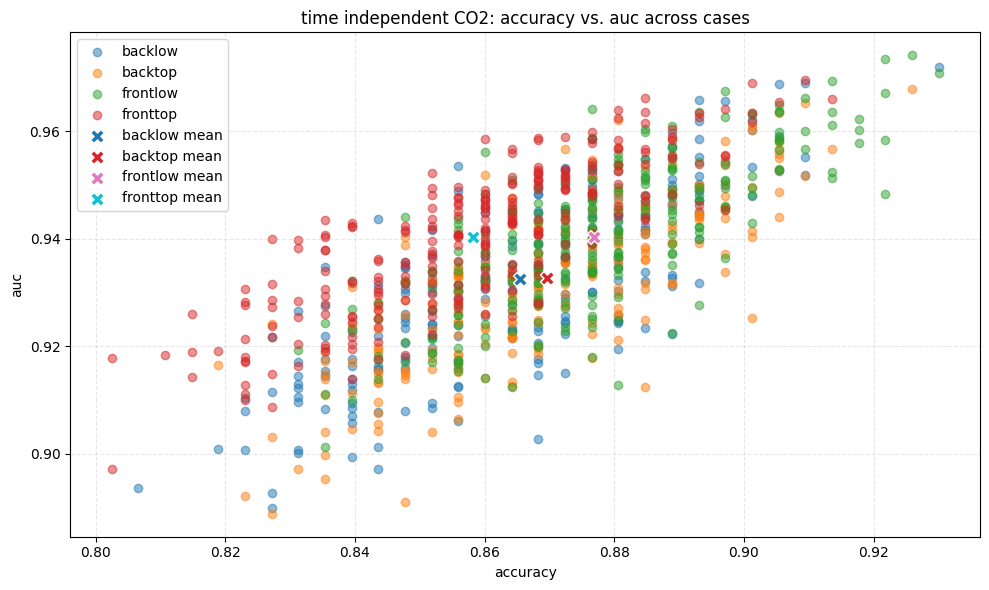

In [12]:
# plot metrics
metrics_plot = ["accuracy", "auc"]

colors = plt.cm.tab10(np.linspace(0, 1, len(case_order)))
case_color_map = {case: color for case, color in zip(case_order, colors)}
plt.figure(figsize=(10, 6))

for case in case_order:
    subset = df_metrics[df_metrics['case'] == case]
    plt.scatter(subset[metrics_plot[0]], subset[metrics_plot[1]], alpha=0.5, label=case)

# average
for case in case_order:
    subset = df_metrics[df_metrics['case'] == case]
    mean_x = subset[metrics_plot[0]].mean()
    mean_y = subset[metrics_plot[1]].mean()
    plt.scatter(mean_x, mean_y, marker='X', color=case_color_map[case], edgecolor='white', s=100, label=f'{case} mean')

plt.xlabel(f"{metrics_plot[0]}")
plt.ylabel(f"{metrics_plot[1]}")
plt.title(f"{model}: {metrics_plot[0]} vs. {metrics_plot[1]} across cases")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

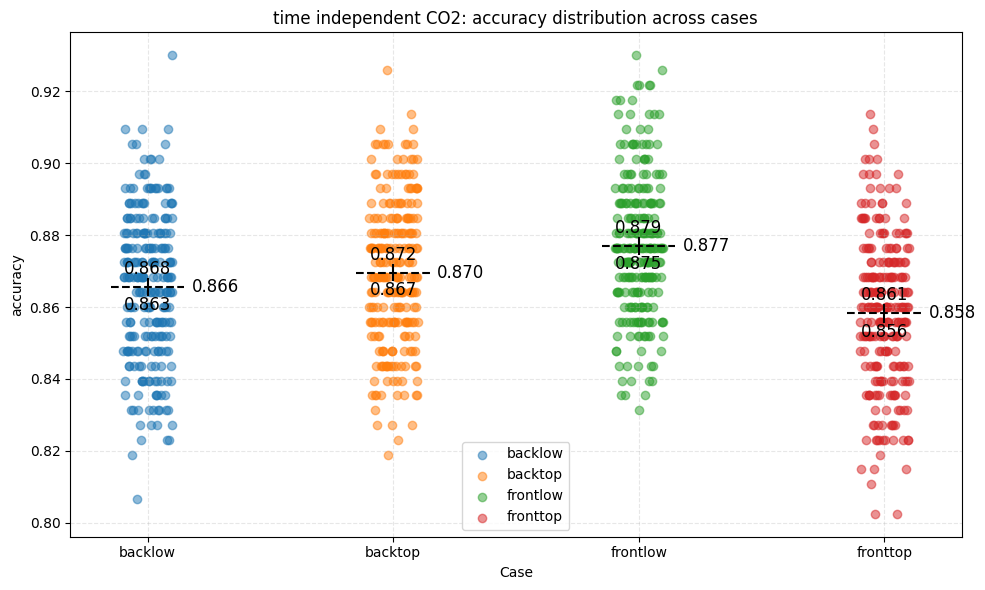

In [13]:
# plot accuracy
metric = "accuracy"

plt.figure(figsize=(10, 6))
for case in case_order:
    subset = df_metrics[df_metrics['case'] == case]
    plt.scatter(subset['x_jitter'], subset[metric], alpha=0.5, label=case)

for i, case in enumerate(case_order):
    vals = df_metrics[df_metrics['case'] == case][metric].values
    n = len(vals)
    mean_val = np.mean(vals)
    sem = stats.sem(vals)                  # standard error
    ci_low, ci_high = stats.t.interval(
        0.95, n - 1, loc=mean_val, scale=sem
    )
    plt.hlines(mean_val, i - 0.15, i + 0.15, colors='black', linestyles='dashed')
    plt.text(i + 0.18, mean_val, f"{mean_val:.3f}", va="center", ha="left", fontsize=12, color="black")
    plt.vlines(i, ci_low, ci_high, colors='black', linewidth=1.5)
    plt.text(i, ci_low, f"{ci_low:.3f}", va="top", ha="center", fontsize=12, color="black")
    plt.text(i, ci_high, f"{ci_high:.3f}", va="bottom", ha="center", fontsize=12, color="black")

plt.xticks(range(len(case_order)), case_order)
plt.xlabel("Case")
plt.ylabel(metric)
plt.title(f"{model}: {metric} distribution across cases")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

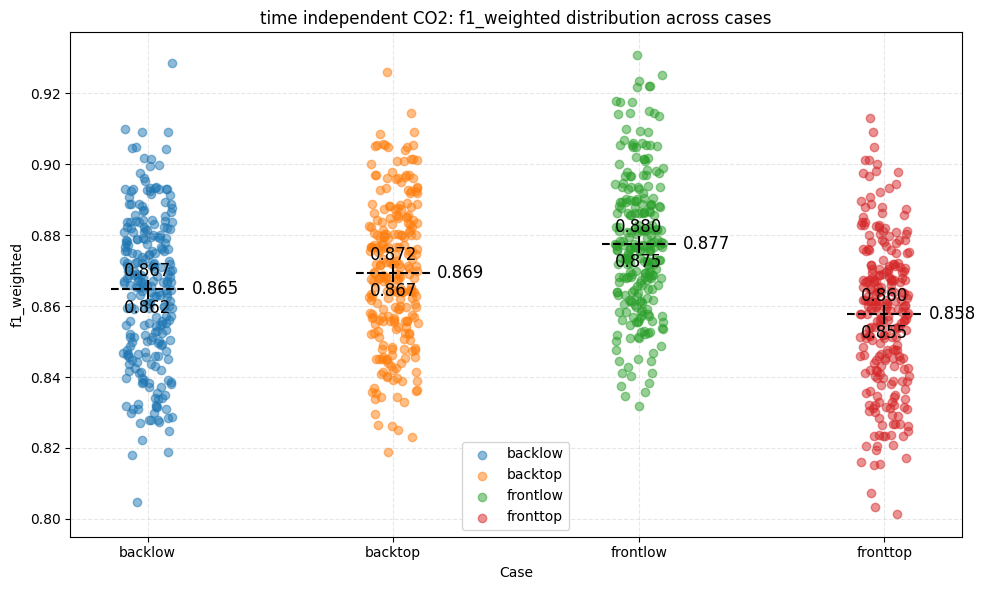

In [14]:
# plot f1 score
metric = "f1_weighted"

plt.figure(figsize=(10, 6))
for case in case_order:
    subset = df_metrics[df_metrics['case'] == case]
    plt.scatter(subset['x_jitter'], subset[metric], alpha=0.5, label=case)

for i, case in enumerate(case_order):
    vals = df_metrics[df_metrics['case'] == case][metric].values
    n = len(vals)
    mean_val = np.mean(vals)
    sem = stats.sem(vals)                  # standard error
    ci_low, ci_high = stats.t.interval(
        0.95, n - 1, loc=mean_val, scale=sem
    )
    plt.hlines(mean_val, i - 0.15, i + 0.15, colors='black', linestyles='dashed')
    plt.text(i + 0.18, mean_val, f"{mean_val:.3f}", va="center", ha="left", fontsize=12, color="black")
    plt.vlines(i, ci_low, ci_high, colors='black', linewidth=1.5)
    plt.text(i, ci_low, f"{ci_low:.3f}", va="top", ha="center", fontsize=12, color="black")
    plt.text(i, ci_high, f"{ci_high:.3f}", va="bottom", ha="center", fontsize=12, color="black")

plt.xticks(range(len(case_order)), case_order)
plt.xlabel("Case")
plt.ylabel(metric)
plt.title(f"{model}: {metric} distribution across cases")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

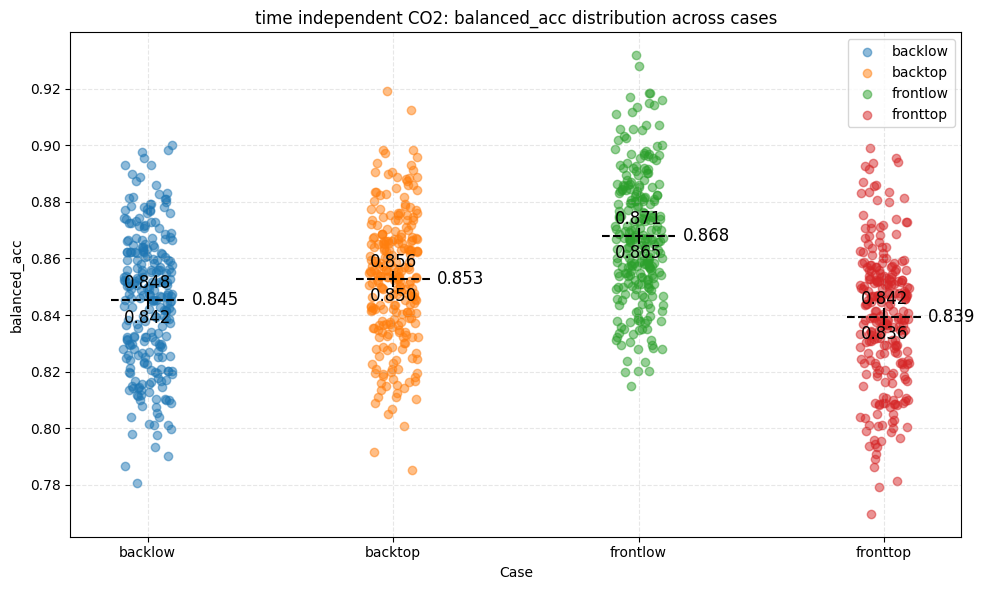

In [15]:
# plot balanced accuracy
metric = "balanced_acc"

plt.figure(figsize=(10, 6))
for case in case_order:
    subset = df_metrics[df_metrics['case'] == case]
    plt.scatter(subset['x_jitter'], subset[metric], alpha=0.5, label=case)

for i, case in enumerate(case_order):
    vals = df_metrics[df_metrics['case'] == case][metric].values
    n = len(vals)
    mean_val = np.mean(vals)
    sem = stats.sem(vals)                  # standard error
    ci_low, ci_high = stats.t.interval(
        0.95, n - 1, loc=mean_val, scale=sem
    )
    plt.hlines(mean_val, i - 0.15, i + 0.15, colors='black', linestyles='dashed')
    plt.text(i + 0.18, mean_val, f"{mean_val:.3f}", va="center", ha="left", fontsize=12, color="black")
    plt.vlines(i, ci_low, ci_high, colors='black', linewidth=1.5)
    plt.text(i, ci_low, f"{ci_low:.3f}", va="top", ha="center", fontsize=12, color="black")
    plt.text(i, ci_high, f"{ci_high:.3f}", va="bottom", ha="center", fontsize=12, color="black")

plt.xticks(range(len(case_order)), case_order)
plt.xlabel("Case")
plt.ylabel(metric)
plt.title(f"{model}: {metric} distribution across cases")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

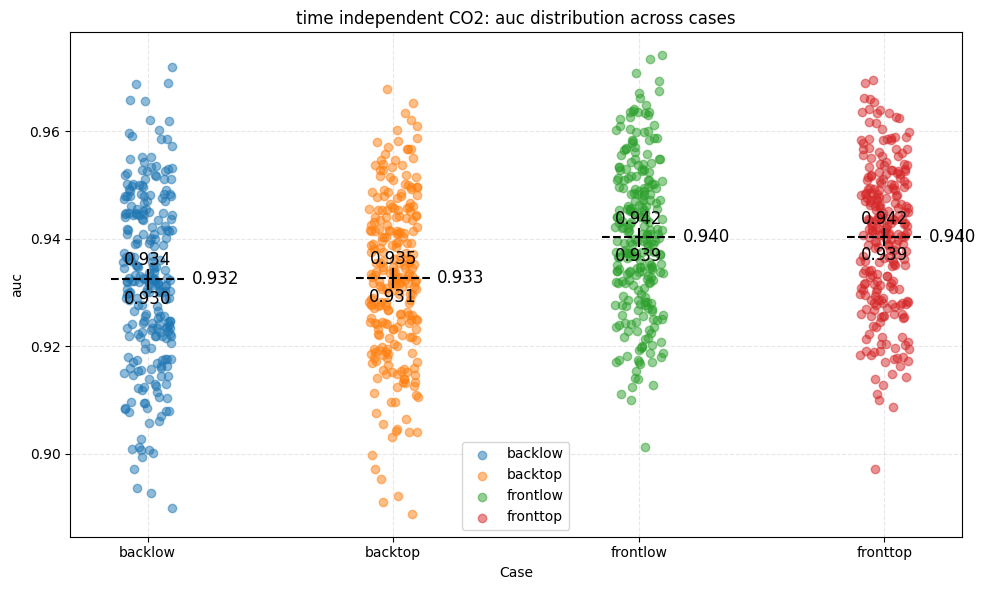

In [16]:
# plot auc
metric = "auc"

plt.figure(figsize=(10, 6))
for case in case_order:
    subset = df_metrics[df_metrics['case'] == case]
    plt.scatter(subset['x_jitter'], subset[metric], alpha=0.5, label=case)

for i, case in enumerate(case_order):
    vals = df_metrics[df_metrics['case'] == case][metric].values
    n = len(vals)
    mean_val = np.mean(vals)
    sem = stats.sem(vals)                  # standard error
    ci_low, ci_high = stats.t.interval(
        0.95, n - 1, loc=mean_val, scale=sem
    )
    plt.hlines(mean_val, i - 0.15, i + 0.15, colors='black', linestyles='dashed')
    plt.text(i + 0.18, mean_val, f"{mean_val:.3f}", va="center", ha="left", fontsize=12, color="black")
    plt.vlines(i, ci_low, ci_high, colors='black', linewidth=1.5)
    plt.text(i, ci_low, f"{ci_low:.3f}", va="top", ha="center", fontsize=12, color="black")
    plt.text(i, ci_high, f"{ci_high:.3f}", va="bottom", ha="center", fontsize=12, color="black")

plt.xticks(range(len(case_order)), case_order)
plt.xlabel("Case")
plt.ylabel(metric)
plt.title(f"{model}: {metric} distribution across cases")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

In [17]:
print(model)
check_anova_assumptions(
    df=df_metrics,
    group_col='case',
    metric_col='accuracy',
    group_order=case_order
)

time independent CO2

=== Normality test (D’Agostino and Pearson) for accuracy ===
backlow                  :	p = 0.4743	→	OK normal
backtop                  :	p = 0.1878	→	OK normal
frontlow                 :	p = 0.2640	→	OK normal
fronttop                 :	p = 0.7843	→	OK normal

=== Normality test (Shapiro-Wilk) for accuracy ===
backlow                  :	p = 0.1107	→	OK normal
backtop                  :	p = 0.1281	→	OK normal
frontlow                 :	p = 0.0264	→	not normal
fronttop                 :	p = 0.2446	→	OK normal

=== Normality test (Anderson-Darling) for accuracy ===
backlow                  :	A² = 0.9284,	5% critical = 0.7750	→	not normal
backtop                  :	A² = 0.7538,	5% critical = 0.7750	→	OK normal
frontlow                 :	A² = 1.0773,	5% critical = 0.7750	→	not normal
fronttop                 :	A² = 0.7674,	5% critical = 0.7750	→	OK normal

=== Homogeneity of variance tests for accuracy ===
Levene’s test  : p = 0.3676	→	OK equal variances
Bartlett’s te

In [18]:
print(model)
check_anova_assumptions(
    df=df_metrics,
    group_col='case',
    metric_col='f1_weighted',
    group_order=case_order
)

time independent CO2

=== Normality test (D’Agostino and Pearson) for f1_weighted ===
backlow                  :	p = 0.3578	→	OK normal
backtop                  :	p = 0.2779	→	OK normal
frontlow                 :	p = 0.2493	→	OK normal
fronttop                 :	p = 0.7264	→	OK normal

=== Normality test (Shapiro-Wilk) for f1_weighted ===
backlow                  :	p = 0.2131	→	OK normal
backtop                  :	p = 0.6119	→	OK normal
frontlow                 :	p = 0.1478	→	OK normal
fronttop                 :	p = 0.5306	→	OK normal

=== Normality test (Anderson-Darling) for f1_weighted ===
backlow                  :	A² = 0.7029,	5% critical = 0.7750	→	OK normal
backtop                  :	A² = 0.2768,	5% critical = 0.7750	→	OK normal
frontlow                 :	A² = 0.5775,	5% critical = 0.7750	→	OK normal
fronttop                 :	A² = 0.5154,	5% critical = 0.7750	→	OK normal

=== Homogeneity of variance tests for f1_weighted ===
Levene’s test  : p = 0.3068	→	OK equal variances
Bart

In [19]:
print(model)
check_anova_assumptions(
    df=df_metrics,
    group_col='case',
    metric_col='balanced_acc',
    group_order=case_order
)

time independent CO2

=== Normality test (D’Agostino and Pearson) for balanced_acc ===
backlow                  :	p = 0.0749	→	OK normal
backtop                  :	p = 0.7279	→	OK normal
frontlow                 :	p = 0.3356	→	OK normal
fronttop                 :	p = 0.6776	→	OK normal

=== Normality test (Shapiro-Wilk) for balanced_acc ===
backlow                  :	p = 0.1456	→	OK normal
backtop                  :	p = 0.8436	→	OK normal
frontlow                 :	p = 0.4575	→	OK normal
fronttop                 :	p = 0.1007	→	OK normal

=== Normality test (Anderson-Darling) for balanced_acc ===
backlow                  :	A² = 0.6883,	5% critical = 0.7750	→	OK normal
backtop                  :	A² = 0.3364,	5% critical = 0.7750	→	OK normal
frontlow                 :	A² = 0.2824,	5% critical = 0.7750	→	OK normal
fronttop                 :	A² = 0.9714,	5% critical = 0.7750	→	not normal

=== Homogeneity of variance tests for balanced_acc ===
Levene’s test  : p = 0.4612	→	OK equal variances

### ANOVA

In [20]:
print(model)
check_anova_assumptions(
    df=df_metrics,
    group_col='case',
    metric_col='auc',
    group_order=case_order
)

time independent CO2

=== Normality test (D’Agostino and Pearson) for auc ===
backlow                  :	p = 0.3023	→	OK normal
backtop                  :	p = 0.1948	→	OK normal
frontlow                 :	p = 0.2371	→	OK normal
fronttop                 :	p = 0.1233	→	OK normal

=== Normality test (Shapiro-Wilk) for auc ===
backlow                  :	p = 0.3287	→	OK normal
backtop                  :	p = 0.2640	→	OK normal
frontlow                 :	p = 0.6462	→	OK normal
fronttop                 :	p = 0.0831	→	OK normal

=== Normality test (Anderson-Darling) for auc ===
backlow                  :	A² = 0.5119,	5% critical = 0.7750	→	OK normal
backtop                  :	A² = 0.3180,	5% critical = 0.7750	→	OK normal
frontlow                 :	A² = 0.2241,	5% critical = 0.7750	→	OK normal
fronttop                 :	A² = 0.7068,	5% critical = 0.7750	→	OK normal

=== Homogeneity of variance tests for auc ===
Levene’s test  : p = 0.0529	→	OK equal variances
Bartlett’s test: p = 0.0283	→	unequa

In [21]:
print(model)
run_anova_full(
    df=df_metrics,
    group_col='case',
    metric_col='accuracy'
)

time independent CO2

=== Welch ANOVA for accuracy ===
Source  ddof1      ddof2        F        p-unc      np2
  case      3 553.103337 37.83368 2.988562e-22 0.101116

Effect size (partial η², np2) = 0.1011 → medium effect

=== Games-Howell post-hoc test for accuracy ===
       A        B  mean(A)  mean(B)      diff       se         T         df         pval    hedges
 backlow  backtop 0.865547 0.869597 -0.004049 0.001822 -2.222286 497.251749 1.186129e-01 -0.198468
 backlow frontlow 0.865547 0.876938 -0.011391 0.001794 -6.348269 495.483582 2.953565e-09 -0.566951
 backlow fronttop 0.865547 0.858222  0.007325 0.001859  3.940982 497.998661 5.362745e-04  0.351961
 backtop frontlow 0.869597 0.876938 -0.007342 0.001758 -4.175893 497.472483 2.047968e-04 -0.372940
 backtop fronttop 0.869597 0.858222  0.011374 0.001824  6.236958 497.187373 5.722959e-09  0.557010
frontlow fronttop 0.876938 0.858222  0.018716 0.001796 10.421446 495.367697 0.000000e+00  0.930718

=== Pairwise effect sizes for accu

In [22]:
print(model)
run_anova_full(
    df=df_metrics,
    group_col='case',
    metric_col='f1_weighted'
)

time independent CO2

=== Welch ANOVA for f1_weighted ===
Source  ddof1      ddof2        F        p-unc      np2
  case      3 553.010577 42.50228 9.973896e-25 0.111258

Effect size (partial η², np2) = 0.1113 → medium effect

=== Games-Howell post-hoc test for f1_weighted ===
       A        B  mean(A)  mean(B)      diff       se         T         df         pval    hedges
 backlow  backtop 0.864709 0.869275 -0.004566 0.001836 -2.486809 496.659965 6.320267e-02 -0.222092
 backlow frontlow 0.864709 0.877435 -0.012725 0.001805 -7.049262 494.157652 3.659750e-11 -0.629555
 backlow fronttop 0.864709 0.857679  0.007030 0.001877  3.746513 497.975497 1.144894e-03  0.334593
 backtop frontlow 0.869275 0.877435 -0.008159 0.001756 -4.646543 497.340947 2.563264e-05 -0.414973
 backtop fronttop 0.869275 0.857679  0.011596 0.001829  6.339255 496.996048 3.110351e-09  0.566146
frontlow fronttop 0.877435 0.857679  0.019756 0.001798 10.985547 494.736807 1.317835e-13  0.981097

=== Pairwise effect sizes fo

In [23]:
print(model)
run_anova_full(
    df=df_metrics,
    group_col='case',
    metric_col='balanced_acc'
)

time independent CO2

=== Welch ANOVA for balanced_acc ===
Source  ddof1      ddof2         F        p-unc      np2
  case      3 553.069387 69.777864 2.786048e-38 0.172585

Effect size (partial η², np2) = 0.1726 → large effect

=== Games-Howell post-hoc test for balanced_acc ===
       A        B  mean(A)  mean(B)      diff       se          T         df         pval    hedges
 backlow  backtop 0.845302 0.852761 -0.007459 0.002087  -3.574578 495.545688 2.173910e-03 -0.319238
 backlow frontlow 0.845302 0.867786 -0.022484 0.002095 -10.731236 496.120414 3.584910e-13 -0.958385
 backlow fronttop 0.845302 0.839307  0.005995 0.002157   2.779272 497.998728 2.881283e-02  0.248211
 backtop frontlow 0.852761 0.867786 -0.015026 0.002021  -7.435602 497.960886 2.847056e-12 -0.664058
 backtop fronttop 0.852761 0.839307  0.013454 0.002085   6.453203 495.654867 1.565084e-09  0.576322
frontlow fronttop 0.867786 0.839307  0.028479 0.002093  13.604007 496.216074 1.859624e-13  1.214946

=== Pairwise effec

In [24]:
print(model)
run_anova_full(
    df=df_metrics,
    group_col='case',
    metric_col='auc'
)

time independent CO2

=== Welch ANOVA for auc ===
Source  ddof1      ddof2         F        p-unc     np2
  case      3 552.263976 23.028755 4.651944e-14 0.06495

Effect size (partial η², np2) = 0.0649 → medium effect

=== Games-Howell post-hoc test for auc ===
       A        B  mean(A)  mean(B)      diff       se         T         df         pval    hedges
 backlow  backtop 0.932465 0.932694 -0.000229 0.001383 -0.165823 495.827169 9.983767e-01 -0.014809
 backlow frontlow 0.932465 0.940249 -0.007785 0.001339 -5.815567 488.712079 6.545045e-08 -0.519376
 backlow fronttop 0.932465 0.940251 -0.007786 0.001318 -5.905565 483.541391 3.971037e-08 -0.527414
 backtop frontlow 0.932694 0.940249 -0.007555 0.001290 -5.854866 495.408937 5.210373e-08 -0.522886
 backtop fronttop 0.932694 0.940251 -0.007557 0.001270 -5.952481 492.262731 3.009602e-08 -0.531604
frontlow fronttop 0.940249 0.940251 -0.000001 0.001221 -0.001162 497.358339 1.000000e+00 -0.000104

=== Pairwise effect sizes for auc (Hedges' g

## Time series - CO2

In [25]:
model = "time series CO2"
backlow = pd.read_csv("../_timeseries_results_raw/case_room1_backlow_state_timeseries_co2.csv")
backtop = pd.read_csv("../_timeseries_results_raw/case_room1_backtop_state_timeseries_co2.csv")
frontlow = pd.read_csv("../_timeseries_results_raw/case_room1_frontlow_state_timeseries_co2.csv")
fronttop = pd.read_csv("../_timeseries_results_raw/case_room1_fronttop_state_timeseries_co2.csv")

In [26]:
backlow.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
random_seed,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
accuracy,250.0,0.859769,0.034415,0.742222,0.844444,0.862222,0.888889,0.924444
f1,250.0,0.831801,0.039089,0.582090,0.809524,0.827586,0.862678,0.909091
balanced_acc,250.0,0.857928,0.032022,0.700678,0.837896,0.853710,0.883929,0.924363
auc,250.0,0.909109,0.009869,0.832788,0.905075,0.911000,0.915311,0.927100
feature_importance.backlow_CO2_scaled,250.0,0.322075,0.099738,0.007556,0.276889,0.367111,0.390556,0.450667
feature_importance.backlow_CO2_fd1_scaled,250.0,0.086395,0.061555,-0.001333,0.031556,0.080222,0.127111,0.294667
feature_importance.backlow_CO2_fd2_scaled,250.0,0.081721,0.060209,-0.003111,0.024333,0.075333,0.130556,0.285333
feature_importance.backlow_CO2_fd3_scaled,250.0,0.076110,0.061124,-0.008889,0.021222,0.070444,0.118556,0.325333


In [27]:
backtop.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
random_seed,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
accuracy,250.0,0.842630,0.054333,0.579909,0.831050,0.853881,0.867580,0.917808
f1,250.0,0.780029,0.143208,0.000000,0.779485,0.813953,0.833092,0.900000
balanced_acc,250.0,0.825259,0.066634,0.500000,0.814832,0.841065,0.856577,0.912658
auc,250.0,0.916168,0.018180,0.849795,0.906517,0.917922,0.928107,0.959517
feature_importance.backtop_CO2_scaled,250.0,0.131887,0.147771,-0.080822,0.019749,0.068265,0.233447,0.523744
feature_importance.backtop_CO2_fd1_scaled,250.0,0.093806,0.072474,-0.019635,0.023858,0.092237,0.150457,0.300000
feature_importance.backtop_CO2_fd2_scaled,250.0,0.075200,0.067965,-0.044749,0.014384,0.060046,0.124886,0.261187
feature_importance.backtop_CO2_fd3_scaled,250.0,0.076007,0.067173,-0.036073,0.015639,0.068265,0.118950,0.317352


In [28]:
frontlow.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
random_seed,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
accuracy,250.0,0.801582,0.045333,0.586667,0.768889,0.795556,0.844444,0.875556
f1,250.0,0.751723,0.085187,0.000000,0.732838,0.762140,0.800000,0.840909
balanced_acc,250.0,0.794235,0.048523,0.496241,0.770595,0.795235,0.831879,0.864580
auc,250.0,0.885157,0.019732,0.780566,0.872160,0.886605,0.899620,0.926773
feature_importance.frontlow_CO2_scaled,250.0,0.188380,0.082710,-0.010222,0.138667,0.212222,0.254667,0.315111
feature_importance.frontlow_CO2_fd1_scaled,250.0,0.054852,0.048882,-0.036444,0.022667,0.040889,0.073778,0.247111
feature_importance.frontlow_CO2_fd2_scaled,250.0,0.056907,0.044525,-0.018222,0.023556,0.049333,0.084222,0.254667
feature_importance.frontlow_CO2_fd3_scaled,250.0,0.055596,0.051455,-0.033333,0.018222,0.043111,0.082111,0.237778


In [29]:
fronttop.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
random_seed,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
accuracy,250.0,0.857863,0.041123,0.602740,0.845890,0.858447,0.880137,0.922374
f1,250.0,0.815590,0.081431,0.155340,0.803035,0.820809,0.853157,0.909091
balanced_acc,250.0,0.846643,0.050647,0.531667,0.832452,0.846499,0.873106,0.922586
auc,250.0,0.926673,0.011267,0.885228,0.920704,0.927764,0.934397,0.950188
feature_importance.fronttop_CO2_scaled,250.0,0.268974,0.132808,0.004566,0.159475,0.272603,0.387443,0.538356
feature_importance.fronttop_CO2_fd1_scaled,250.0,0.026544,0.032358,-0.021918,0.007420,0.017580,0.035502,0.258904
feature_importance.fronttop_CO2_fd2_scaled,250.0,0.025289,0.034408,-0.029680,0.004566,0.014840,0.035845,0.227397
feature_importance.fronttop_CO2_fd3_scaled,250.0,0.020327,0.034975,-0.053881,0.002283,0.012557,0.030594,0.273059


In [30]:
backlow['case'] = 'backlow'
backtop['case'] = 'backtop'
frontlow['case'] = 'frontlow'
fronttop['case'] = 'fronttop'

metrics = ["case", "accuracy", "f1", "balanced_acc", "auc"]

df_metrics = pd.concat(
    [
        backlow[metrics],
        backtop[metrics],
        frontlow[metrics],
        fronttop[metrics]
    ],
    ignore_index=True
)

df_metrics.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   case          1000 non-null   object 
 1   accuracy      1000 non-null   float64
 2   f1            1000 non-null   float64
 3   balanced_acc  1000 non-null   float64
 4   auc           1000 non-null   float64
dtypes: float64(4), object(1)
memory usage: 39.2+ KB


In [31]:
case_order = ['backlow', 'backtop', 'frontlow', 'fronttop']
df_metrics['x'] = df_metrics['case'].map({name: i for i, name in enumerate(case_order)})
df_metrics['x_jitter'] = df_metrics['x'] + np.random.uniform(-0.1, 0.1, size=len(df_metrics))

df_metrics.head().T

,0,1,2,3,4
case,backlow,backlow,backlow,backlow,backlow
accuracy,0.866667,0.862222,0.893333,0.857778,0.857778
f1,0.827586,0.816568,0.866667,0.831579,0.813953
balanced_acc,0.85371,0.844925,0.886319,0.857919,0.842841
auc,0.902746,0.893756,0.896535,0.912226,0.910919
x,0,0,0,0,0
x_jitter,0.033235,0.091265,-0.029172,-0.081417,-0.027152


### plot

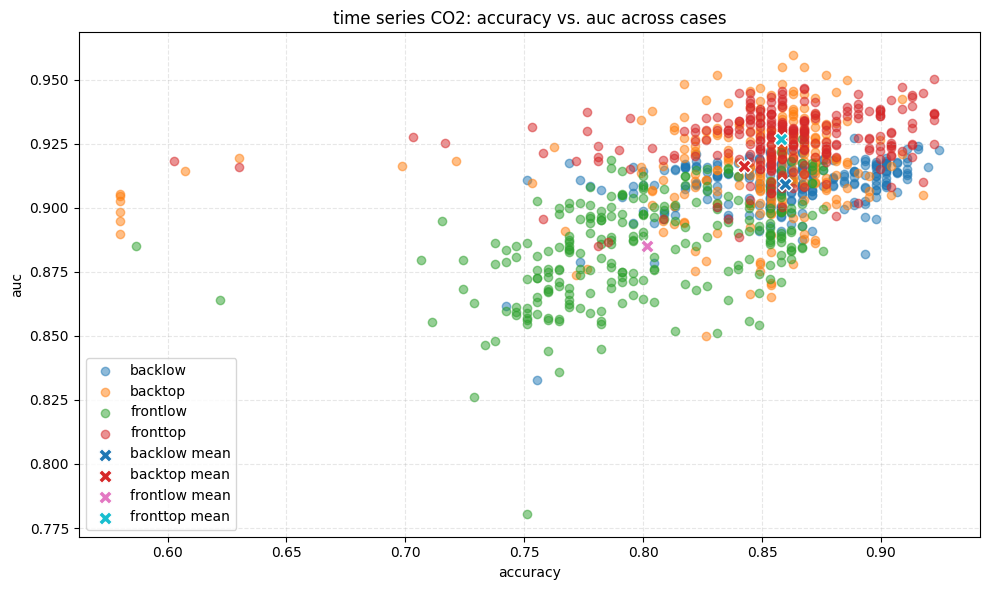

In [32]:
# plot metrics
metrics_plot = ["accuracy", "auc"]

colors = plt.cm.tab10(np.linspace(0, 1, len(case_order)))
case_color_map = {case: color for case, color in zip(case_order, colors)}
plt.figure(figsize=(10, 6))

for case in case_order:
    subset = df_metrics[df_metrics['case'] == case]
    plt.scatter(subset[metrics_plot[0]], subset[metrics_plot[1]], alpha=0.5, label=case)

# average
for case in case_order:
    subset = df_metrics[df_metrics['case'] == case]
    mean_x = subset[metrics_plot[0]].mean()
    mean_y = subset[metrics_plot[1]].mean()
    plt.scatter(mean_x, mean_y, marker='X', color=case_color_map[case], edgecolor='white', s=100, label=f'{case} mean')

plt.xlabel(f"{metrics_plot[0]}")
plt.ylabel(f"{metrics_plot[1]}")
plt.title(f"{model}: {metrics_plot[0]} vs. {metrics_plot[1]} across cases")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

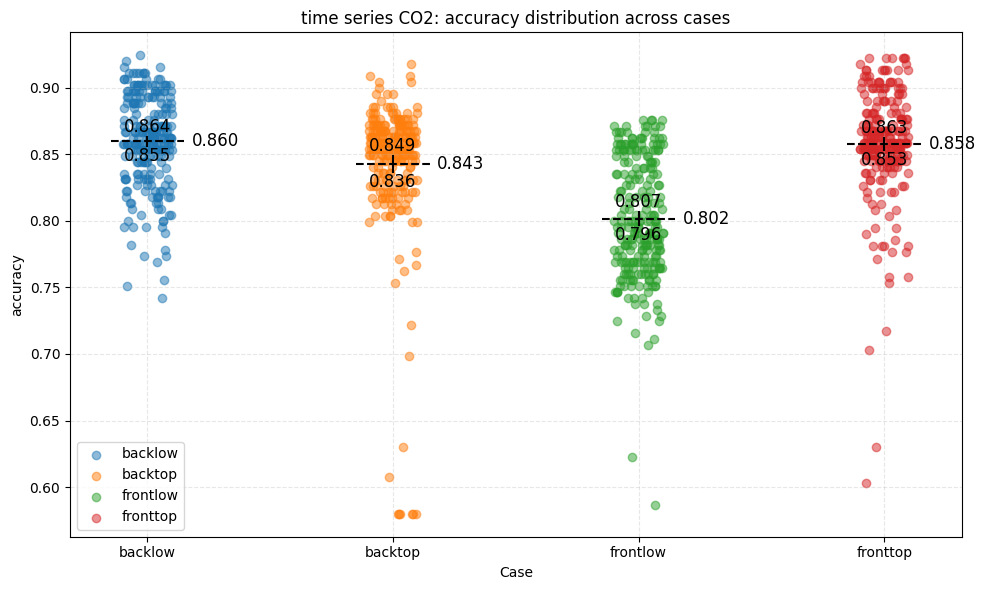

In [33]:
# plot accuracy
metric = "accuracy"

plt.figure(figsize=(10, 6))
for case in case_order:
    subset = df_metrics[df_metrics['case'] == case]
    plt.scatter(subset['x_jitter'], subset[metric], alpha=0.5, label=case)

for i, case in enumerate(case_order):
    vals = df_metrics[df_metrics['case'] == case][metric].values
    n = len(vals)
    mean_val = np.mean(vals)
    sem = stats.sem(vals)                  # standard error
    ci_low, ci_high = stats.t.interval(
        0.95, n - 1, loc=mean_val, scale=sem
    )
    plt.hlines(mean_val, i - 0.15, i + 0.15, colors='black', linestyles='dashed')
    plt.text(i + 0.18, mean_val, f"{mean_val:.3f}", va="center", ha="left", fontsize=12, color="black")
    plt.vlines(i, ci_low, ci_high, colors='black', linewidth=1.5)
    plt.text(i, ci_low, f"{ci_low:.3f}", va="top", ha="center", fontsize=12, color="black")
    plt.text(i, ci_high, f"{ci_high:.3f}", va="bottom", ha="center", fontsize=12, color="black")

plt.xticks(range(len(case_order)), case_order)
plt.xlabel("Case")
plt.ylabel(metric)
plt.title(f"{model}: {metric} distribution across cases")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

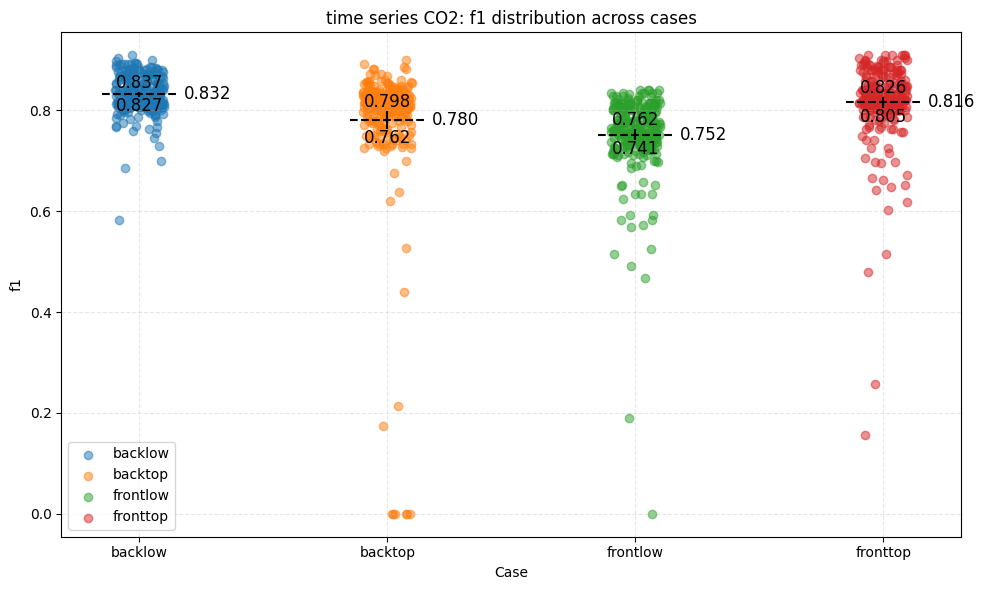

In [34]:
# plot f1 score
metric = "f1"

plt.figure(figsize=(10, 6))
for case in case_order:
    subset = df_metrics[df_metrics['case'] == case]
    plt.scatter(subset['x_jitter'], subset[metric], alpha=0.5, label=case)

for i, case in enumerate(case_order):
    vals = df_metrics[df_metrics['case'] == case][metric].values
    n = len(vals)
    mean_val = np.mean(vals)
    sem = stats.sem(vals)                  # standard error
    ci_low, ci_high = stats.t.interval(
        0.95, n - 1, loc=mean_val, scale=sem
    )
    plt.hlines(mean_val, i - 0.15, i + 0.15, colors='black', linestyles='dashed')
    plt.text(i + 0.18, mean_val, f"{mean_val:.3f}", va="center", ha="left", fontsize=12, color="black")
    plt.vlines(i, ci_low, ci_high, colors='black', linewidth=1.5)
    plt.text(i, ci_low, f"{ci_low:.3f}", va="top", ha="center", fontsize=12, color="black")
    plt.text(i, ci_high, f"{ci_high:.3f}", va="bottom", ha="center", fontsize=12, color="black")

plt.xticks(range(len(case_order)), case_order)
plt.xlabel("Case")
plt.ylabel(metric)
plt.title(f"{model}: {metric} distribution across cases")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

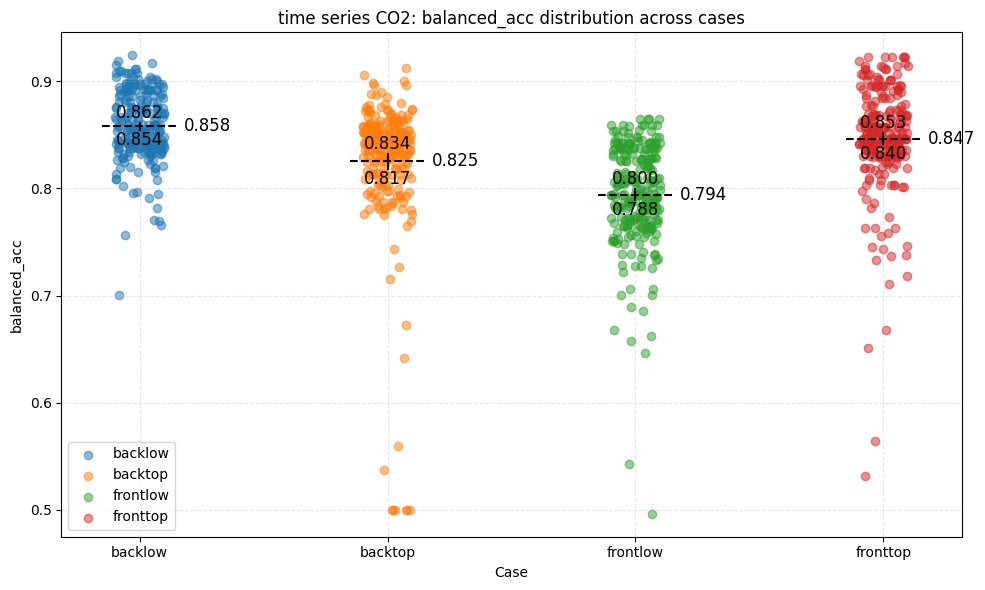

In [35]:
# plot balanced accuracy
metric = "balanced_acc"

plt.figure(figsize=(10, 6))
for case in case_order:
    subset = df_metrics[df_metrics['case'] == case]
    plt.scatter(subset['x_jitter'], subset[metric], alpha=0.5, label=case)

for i, case in enumerate(case_order):
    vals = df_metrics[df_metrics['case'] == case][metric].values
    n = len(vals)
    mean_val = np.mean(vals)
    sem = stats.sem(vals)                  # standard error
    ci_low, ci_high = stats.t.interval(
        0.95, n - 1, loc=mean_val, scale=sem
    )
    plt.hlines(mean_val, i - 0.15, i + 0.15, colors='black', linestyles='dashed')
    plt.text(i + 0.18, mean_val, f"{mean_val:.3f}", va="center", ha="left", fontsize=12, color="black")
    plt.vlines(i, ci_low, ci_high, colors='black', linewidth=1.5)
    plt.text(i, ci_low, f"{ci_low:.3f}", va="top", ha="center", fontsize=12, color="black")
    plt.text(i, ci_high, f"{ci_high:.3f}", va="bottom", ha="center", fontsize=12, color="black")

plt.xticks(range(len(case_order)), case_order)
plt.xlabel("Case")
plt.ylabel(metric)
plt.title(f"{model}: {metric} distribution across cases")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

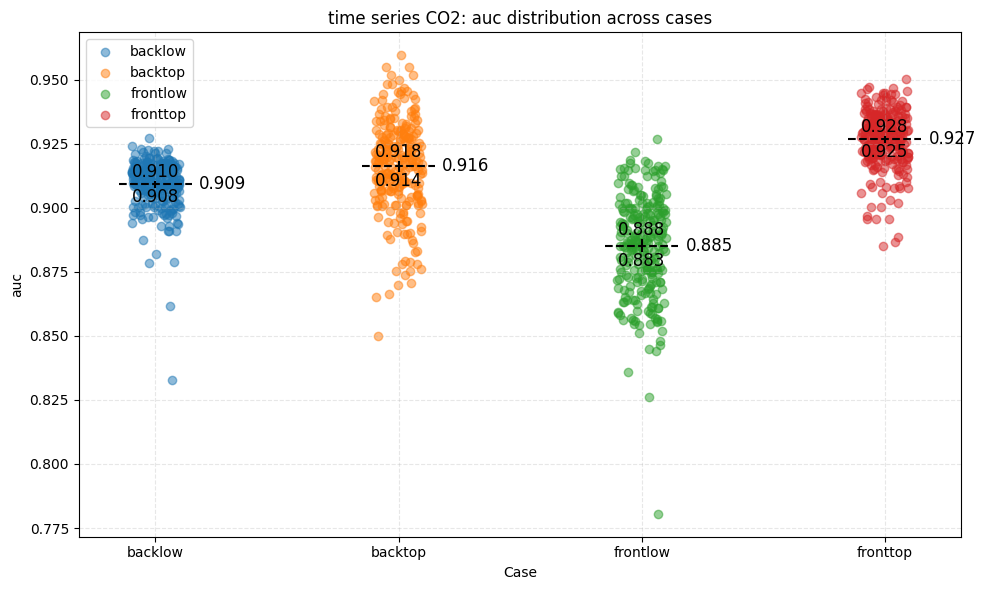

In [36]:
# plot auc
metric = "auc"

plt.figure(figsize=(10, 6))
for case in case_order:
    subset = df_metrics[df_metrics['case'] == case]
    plt.scatter(subset['x_jitter'], subset[metric], alpha=0.5, label=case)

for i, case in enumerate(case_order):
    vals = df_metrics[df_metrics['case'] == case][metric].values
    n = len(vals)
    mean_val = np.mean(vals)
    sem = stats.sem(vals)                  # standard error
    ci_low, ci_high = stats.t.interval(
        0.95, n - 1, loc=mean_val, scale=sem
    )
    plt.hlines(mean_val, i - 0.15, i + 0.15, colors='black', linestyles='dashed')
    plt.text(i + 0.18, mean_val, f"{mean_val:.3f}", va="center", ha="left", fontsize=12, color="black")
    plt.vlines(i, ci_low, ci_high, colors='black', linewidth=1.5)
    plt.text(i, ci_low, f"{ci_low:.3f}", va="top", ha="center", fontsize=12, color="black")
    plt.text(i, ci_high, f"{ci_high:.3f}", va="bottom", ha="center", fontsize=12, color="black")

plt.xticks(range(len(case_order)), case_order)
plt.xlabel("Case")
plt.ylabel(metric)
plt.title(f"{model}: {metric} distribution across cases")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

In [37]:
print(model)
check_anova_assumptions(
    df=df_metrics,
    group_col='case',
    metric_col='accuracy',
    group_order=case_order
)

time series CO2

=== Normality test (D’Agostino and Pearson) for accuracy ===
backlow                  :	p = 0.0001	→	not normal
backtop                  :	p = 0.0000	→	not normal
frontlow                 :	p = 0.0000	→	not normal
fronttop                 :	p = 0.0000	→	not normal

=== Normality test (Shapiro-Wilk) for accuracy ===
backlow                  :	p = 0.0000	→	not normal
backtop                  :	p = 0.0000	→	not normal
frontlow                 :	p = 0.0000	→	not normal
fronttop                 :	p = 0.0000	→	not normal

=== Normality test (Anderson-Darling) for accuracy ===
backlow                  :	A² = 2.4325,	5% critical = 0.7750	→	not normal
backtop                  :	A² = 24.9425,	5% critical = 0.7750	→	not normal
frontlow                 :	A² = 3.0841,	5% critical = 0.7750	→	not normal
fronttop                 :	A² = 8.4902,	5% critical = 0.7750	→	not normal

=== Homogeneity of variance tests for accuracy ===
Levene’s test  : p = 0.0006	→	unequal variances
Bartlett’

In [38]:
print(model)
check_anova_assumptions(
    df=df_metrics,
    group_col='case',
    metric_col='f1',
    group_order=case_order
)

time series CO2

=== Normality test (D’Agostino and Pearson) for f1 ===
backlow                  :	p = 0.0000	→	not normal
backtop                  :	p = 0.0000	→	not normal
frontlow                 :	p = 0.0000	→	not normal
fronttop                 :	p = 0.0000	→	not normal

=== Normality test (Shapiro-Wilk) for f1 ===
backlow                  :	p = 0.0000	→	not normal
backtop                  :	p = 0.0000	→	not normal
frontlow                 :	p = 0.0000	→	not normal
fronttop                 :	p = 0.0000	→	not normal

=== Normality test (Anderson-Darling) for f1 ===
backlow                  :	A² = 2.9616,	5% critical = 0.7750	→	not normal
backtop                  :	A² = 44.4138,	5% critical = 0.7750	→	not normal
frontlow                 :	A² = 16.8882,	5% critical = 0.7750	→	not normal
fronttop                 :	A² = 17.6390,	5% critical = 0.7750	→	not normal

=== Homogeneity of variance tests for f1 ===
Levene’s test  : p = 0.0046	→	unequal variances
Bartlett’s test: p = 0.0000	→	u

In [39]:
print(model)
check_anova_assumptions(
    df=df_metrics,
    group_col='case',
    metric_col='balanced_acc',
    group_order=case_order
)

time series CO2

=== Normality test (D’Agostino and Pearson) for balanced_acc ===
backlow                  :	p = 0.0000	→	not normal
backtop                  :	p = 0.0000	→	not normal
frontlow                 :	p = 0.0000	→	not normal
fronttop                 :	p = 0.0000	→	not normal

=== Normality test (Shapiro-Wilk) for balanced_acc ===
backlow                  :	p = 0.0000	→	not normal
backtop                  :	p = 0.0000	→	not normal
frontlow                 :	p = 0.0000	→	not normal
fronttop                 :	p = 0.0000	→	not normal

=== Normality test (Anderson-Darling) for balanced_acc ===
backlow                  :	A² = 2.3389,	5% critical = 0.7750	→	not normal
backtop                  :	A² = 25.7830,	5% critical = 0.7750	→	not normal
frontlow                 :	A² = 3.7394,	5% critical = 0.7750	→	not normal
fronttop                 :	A² = 8.5218,	5% critical = 0.7750	→	not normal

=== Homogeneity of variance tests for balanced_acc ===
Levene’s test  : p = 0.0216	→	unequal var

In [40]:
print(model)
check_anova_assumptions(
    df=df_metrics,
    group_col='case',
    metric_col='auc',
    group_order=case_order
)

time series CO2

=== Normality test (D’Agostino and Pearson) for auc ===
backlow                  :	p = 0.0000	→	not normal
backtop                  :	p = 0.0011	→	not normal
frontlow                 :	p = 0.0000	→	not normal
fronttop                 :	p = 0.0000	→	not normal

=== Normality test (Shapiro-Wilk) for auc ===
backlow                  :	p = 0.0000	→	not normal
backtop                  :	p = 0.0041	→	not normal
frontlow                 :	p = 0.0000	→	not normal
fronttop                 :	p = 0.0000	→	not normal

=== Normality test (Anderson-Darling) for auc ===
backlow                  :	A² = 6.6379,	5% critical = 0.7750	→	not normal
backtop                  :	A² = 1.0334,	5% critical = 0.7750	→	not normal
frontlow                 :	A² = 0.8409,	5% critical = 0.7750	→	not normal
fronttop                 :	A² = 2.0979,	5% critical = 0.7750	→	not normal

=== Homogeneity of variance tests for auc ===
Levene’s test  : p = 0.0000	→	unequal variances
Bartlett’s test: p = 0.0000	→	

### ANOVA

In [41]:
print(model)
run_anova_full(
    df=df_metrics,
    group_col='case',
    metric_col='accuracy'
)

time series CO2

=== Welch ANOVA for accuracy ===
Source  ddof1      ddof2         F        p-unc      np2
  case      3 546.864913 99.730449 1.684586e-51 0.218251

Effect size (partial η², np2) = 0.2183 → large effect

=== Games-Howell post-hoc test for accuracy ===
       A        B  mean(A)  mean(B)      diff       se          T         df         pval    hedges
 backlow  backtop 0.859769 0.842630  0.017139 0.004068   4.213439 421.098502 1.800446e-04  0.376294
 backlow frontlow 0.859769 0.801582  0.058187 0.003600  16.164365 464.448102 2.843281e-13  1.443606
 backlow fronttop 0.859769 0.857863  0.001906 0.003391   0.561963 482.999638 9.432420e-01  0.050188
 backtop frontlow 0.842630 0.801582  0.041048 0.004475   9.172078 482.515116 1.322276e-13  0.819139
 backtop fronttop 0.842630 0.857863 -0.015233 0.004310  -3.534635 463.796292 2.526967e-03 -0.315671
frontlow fronttop 0.801582 0.857863 -0.056281 0.003871 -14.539035 493.343936 2.986500e-14 -1.298451

=== Pairwise effect sizes for a

In [42]:
print(model)
run_anova_full(
    df=df_metrics,
    group_col='case',
    metric_col='f1'
)

time series CO2

=== Welch ANOVA for f1 ===
Source  ddof1      ddof2         F        p-unc      np2
  case      3 501.965439 66.135829 4.733301e-36 0.097719

Effect size (partial η², np2) = 0.0977 → medium effect

=== Games-Howell post-hoc test for f1 ===
       A        B  mean(A)  mean(B)      diff       se         T         df         pval    hedges
 backlow  backtop 0.831801 0.780029  0.051772 0.009389  5.514362 285.897430 4.680192e-07  0.492476
 backlow frontlow 0.831801 0.751723  0.080078 0.005928 13.508812 349.403137 2.062794e-13  1.206444
 backlow fronttop 0.831801 0.815590  0.016211 0.005713  2.837652 357.965741 2.469006e-02  0.253425
 backtop frontlow 0.780029 0.751723  0.028306 0.010539  2.685924 405.607040 3.762675e-02  0.239874
 backtop fronttop 0.780029 0.815590 -0.035561 0.010419 -3.413086 394.777351 3.938790e-03 -0.304816
frontlow fronttop 0.751723 0.815590 -0.063867 0.007453 -8.569004 496.990555 4.495293e-13 -0.765280

=== Pairwise effect sizes for f1 (Hedges' g) ===


In [43]:
print(model)
run_anova_full(
    df=df_metrics,
    group_col='case',
    metric_col='balanced_acc'
)

time series CO2

=== Welch ANOVA for balanced_acc ===
Source  ddof1      ddof2          F        p-unc     np2
  case      3 534.658998 105.203249 1.553741e-53 0.18542

Effect size (partial η², np2) = 0.1854 → large effect

=== Games-Howell post-hoc test for balanced_acc ===
       A        B  mean(A)  mean(B)      diff       se          T         df         pval    hedges
 backlow  backtop 0.857928 0.825259  0.032669 0.004676   6.987007 358.184997 8.264622e-11  0.623995
 backlow frontlow 0.857928 0.794235  0.063693 0.003677  17.322634 431.306954 3.037570e-13  1.547049
 backlow fronttop 0.857928 0.846643  0.011285 0.003790   2.977929 420.648006 1.616872e-02  0.265953
 backtop frontlow 0.825259 0.794235  0.031024 0.005213   5.950998 455.117546 3.190224e-08  0.531471
 backtop fronttop 0.825259 0.846643 -0.021384 0.005293  -4.039621 464.706341 3.637709e-04 -0.360770
frontlow fronttop 0.794235 0.846643 -0.052408 0.004436 -11.814189 497.088998 2.715606e-13 -1.055101

=== Pairwise effect siz

In [44]:
print(model)
run_anova_full(
    df=df_metrics,
    group_col='case',
    metric_col='auc'
)

time series CO2

=== Welch ANOVA for auc ===
Source  ddof1      ddof2          F         p-unc      np2
  case      3 535.454073 303.237669 5.297781e-115 0.497707

Effect size (partial η², np2) = 0.4977 → large effect

=== Games-Howell post-hoc test for auc ===
       A        B  mean(A)  mean(B)      diff       se          T         df         pval    hedges
 backlow  backtop 0.909109 0.916168 -0.007059 0.001308  -5.395740 384.034097 7.148126e-07 -0.481882
 backlow frontlow 0.909109 0.885157  0.023951 0.001395  17.164783 366.245121 8.038015e-14  1.532952
 backlow fronttop 0.909109 0.926673 -0.017564 0.000947 -18.540515 489.512511 0.000000e+00 -1.655815
 backtop frontlow 0.916168 0.885157  0.031011 0.001697  18.274692 494.694922 1.947331e-13  1.632075
 backtop fronttop 0.916168 0.926673 -0.010504 0.001353  -7.765336 415.683844 6.978862e-13 -0.693506
frontlow fronttop 0.885157 0.926673 -0.041515 0.001437 -28.888201 395.765811 1.814104e-13 -2.579946

=== Pairwise effect sizes for auc (He

## Time independent - CO2temphum

In [45]:
model = "time independent CO2temphum"
backlow = pd.read_csv("../_timeindep_results_raw/case_room1_backlow_state_timeindep_co2temphum.csv")
backtop = pd.read_csv("../_timeindep_results_raw/case_room1_backtop_state_timeindep_co2temphum.csv")
frontlow = pd.read_csv("../_timeindep_results_raw/case_room1_frontlow_state_timeindep_co2temphum.csv")
fronttop = pd.read_csv("../_timeindep_results_raw/case_room1_fronttop_state_timeindep_co2temphum.csv")

In [46]:
backlow.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,250.0,124.500000,72.312977,0.000000,6.225000e+01,124.500000,186.750000,249.000000
random_seed,250.0,124.500000,72.312977,0.000000,6.225000e+01,124.500000,186.750000,249.000000
accuracy,250.0,0.948198,0.013299,0.909465,9.382716e-01,0.946502,0.958848,0.979424
f1_weighted,250.0,0.948544,0.013152,0.911041,9.391047e-01,0.947265,0.958991,0.979501
balanced_acc,250.0,0.949329,0.014238,0.910123,9.407172e-01,0.949922,0.959795,0.981447
auc,250.0,0.985987,0.006160,0.952531,9.823054e-01,0.986663,0.990716,0.997529
model_weights.random_forest,250.0,1.669910,0.358924,0.699822,1.427294e+00,1.681470,1.937823,2.631973
model_weights.bagging_svc,250.0,1.815998,0.325632,0.979960,1.602464e+00,1.825023,2.041905,2.489309
model_weights.bagging_knn,250.0,1.646069,0.374199,0.405673,1.402644e+00,1.644947,1.897327,2.656088
model_weights.gradient_boosting,250.0,1.752216,0.399721,0.612636,1.490962e+00,1.759527,2.040003,2.828264


In [47]:
backtop.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
random_seed,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
accuracy,250.0,0.938864,0.014892,0.884774,0.930041,0.938272,0.950617,0.979424
f1_weighted,250.0,0.939143,0.014841,0.883995,0.930250,0.938794,0.950515,0.979501
balanced_acc,250.0,0.936983,0.017496,0.863190,0.926619,0.939013,0.948419,0.981447
auc,250.0,0.983858,0.006476,0.955675,0.980131,0.984528,0.988521,0.995778
model_weights.random_forest,250.0,2.040990,0.456043,0.879170,1.724265,2.011571,2.373560,3.801406
model_weights.bagging_svc,250.0,1.200365,0.371294,0.079353,0.958208,1.217912,1.461415,2.044210
model_weights.bagging_knn,250.0,0.902127,0.336752,0.057831,0.677076,0.912919,1.132673,2.004116
model_weights.gradient_boosting,250.0,2.339804,0.473022,1.094454,2.039219,2.311392,2.692954,3.549329


In [48]:
frontlow.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
random_seed,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
accuracy,250.0,0.945893,0.012281,0.913580,0.938272,0.946502,0.954733,0.983539
f1_weighted,250.0,0.946247,0.012137,0.914336,0.938553,0.946725,0.954941,0.983539
balanced_acc,250.0,0.946655,0.012999,0.914308,0.938124,0.946991,0.954930,0.980989
auc,250.0,0.983198,0.006968,0.960542,0.978374,0.983886,0.988387,0.995622
model_weights.random_forest,250.0,2.779925,0.451682,1.606349,2.505724,2.733621,3.066796,4.015000
model_weights.bagging_svc,250.0,0.974680,0.308825,0.159387,0.771351,1.003668,1.170073,1.806336
model_weights.bagging_knn,250.0,1.433889,0.339460,0.437407,1.224635,1.430856,1.655789,2.567234
model_weights.gradient_boosting,250.0,1.849655,0.443326,0.572998,1.563105,1.845793,2.124971,3.124099


In [49]:
fronttop.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,250.0,124.500000,72.312977,0.000000,6.225000e+01,124.500000,186.750000,249.000000
random_seed,250.0,124.500000,72.312977,0.000000,6.225000e+01,124.500000,186.750000,249.000000
accuracy,250.0,0.944543,0.014088,0.909465,9.341564e-01,0.946502,0.954733,0.979424
f1_weighted,250.0,0.944836,0.013981,0.909727,9.346891e-01,0.946161,0.955003,0.979521
balanced_acc,250.0,0.943826,0.015799,0.901757,9.328885e-01,0.944268,0.955913,0.981476
auc,250.0,0.985620,0.006362,0.951557,9.813782e-01,0.986484,0.990380,0.996737
model_weights.random_forest,250.0,2.268429,0.438883,0.999753,1.941290e+00,2.257069,2.580311,3.311389
model_weights.bagging_svc,250.0,0.761661,0.333316,-0.175928,5.603376e-01,0.745695,0.983914,1.673598
model_weights.bagging_knn,250.0,1.797749,0.400191,0.556879,1.495385e+00,1.782630,2.088628,3.128260
model_weights.gradient_boosting,250.0,1.599182,0.444850,0.289538,1.326082e+00,1.568788,1.891302,2.712433


In [50]:
backlow['case'] = 'backlow'
backtop['case'] = 'backtop'
frontlow['case'] = 'frontlow'
fronttop['case'] = 'fronttop'

metrics = ["case", "accuracy", "f1_weighted", "balanced_acc", "auc"]

df_metrics = pd.concat(
    [
        backlow[metrics],
        backtop[metrics],
        frontlow[metrics],
        fronttop[metrics]
    ],
    ignore_index=True
)

df_metrics.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   case          1000 non-null   object 
 1   accuracy      1000 non-null   float64
 2   f1_weighted   1000 non-null   float64
 3   balanced_acc  1000 non-null   float64
 4   auc           1000 non-null   float64
dtypes: float64(4), object(1)
memory usage: 39.2+ KB


In [51]:
case_order = ['backlow', 'backtop', 'frontlow', 'fronttop']
df_metrics['x'] = df_metrics['case'].map({name: i for i, name in enumerate(case_order)})
df_metrics['x_jitter'] = df_metrics['x'] + np.random.uniform(-0.1, 0.1, size=len(df_metrics))

df_metrics.head().T

,0,1,2,3,4
case,backlow,backlow,backlow,backlow,backlow
accuracy,0.942387,0.946502,0.917695,0.958848,0.942387
f1_weighted,0.94222,0.946986,0.918744,0.959206,0.943231
balanced_acc,0.933513,0.950678,0.925789,0.96296,0.940118
auc,0.990267,0.993524,0.982299,0.991028,0.987881
x,0,0,0,0,0
x_jitter,0.038118,-0.066618,0.000435,-0.083575,0.043837


### plot

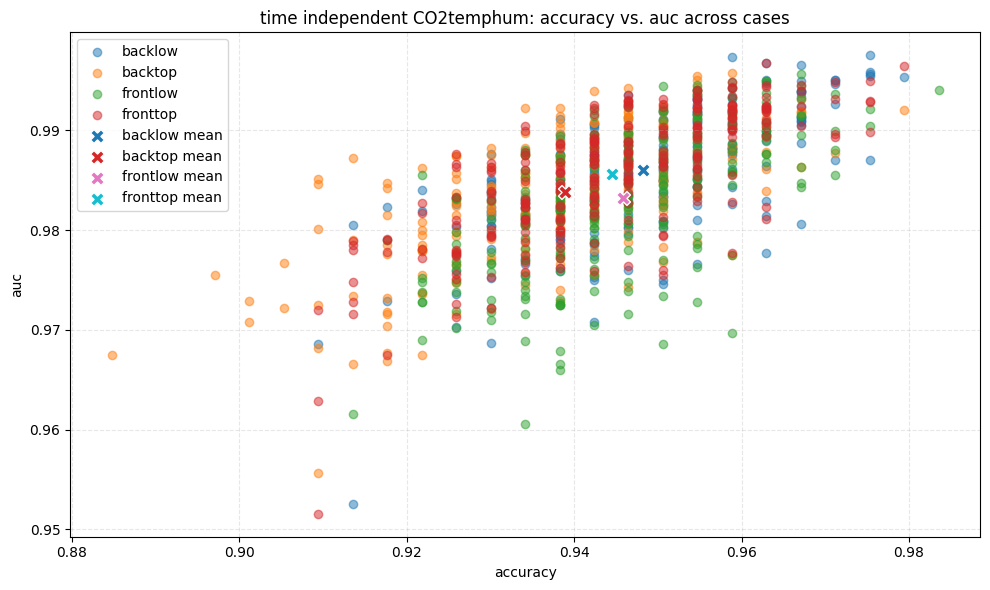

In [52]:
# plot metrics
metrics_plot = ["accuracy", "auc"]

colors = plt.cm.tab10(np.linspace(0, 1, len(case_order)))
case_color_map = {case: color for case, color in zip(case_order, colors)}
plt.figure(figsize=(10, 6))

for case in case_order:
    subset = df_metrics[df_metrics['case'] == case]
    plt.scatter(subset[metrics_plot[0]], subset[metrics_plot[1]], alpha=0.5, label=case)

# average
for case in case_order:
    subset = df_metrics[df_metrics['case'] == case]
    mean_x = subset[metrics_plot[0]].mean()
    mean_y = subset[metrics_plot[1]].mean()
    plt.scatter(mean_x, mean_y, marker='X', color=case_color_map[case], edgecolor='white', s=100, label=f'{case} mean')

plt.xlabel(f"{metrics_plot[0]}")
plt.ylabel(f"{metrics_plot[1]}")
plt.title(f"{model}: {metrics_plot[0]} vs. {metrics_plot[1]} across cases")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

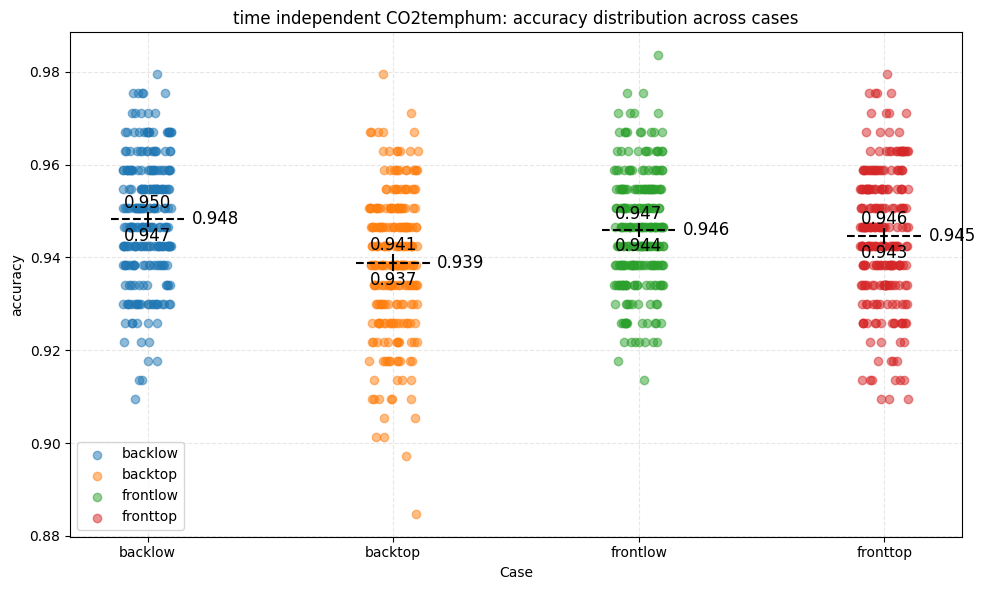

In [53]:
# plot accuracy
metric = "accuracy"

plt.figure(figsize=(10, 6))
for case in case_order:
    subset = df_metrics[df_metrics['case'] == case]
    plt.scatter(subset['x_jitter'], subset[metric], alpha=0.5, label=case)

for i, case in enumerate(case_order):
    vals = df_metrics[df_metrics['case'] == case][metric].values
    n = len(vals)
    mean_val = np.mean(vals)
    sem = stats.sem(vals)                  # standard error
    ci_low, ci_high = stats.t.interval(
        0.95, n - 1, loc=mean_val, scale=sem
    )
    plt.hlines(mean_val, i - 0.15, i + 0.15, colors='black', linestyles='dashed')
    plt.text(i + 0.18, mean_val, f"{mean_val:.3f}", va="center", ha="left", fontsize=12, color="black")
    plt.vlines(i, ci_low, ci_high, colors='black', linewidth=1.5)
    plt.text(i, ci_low, f"{ci_low:.3f}", va="top", ha="center", fontsize=12, color="black")
    plt.text(i, ci_high, f"{ci_high:.3f}", va="bottom", ha="center", fontsize=12, color="black")

plt.xticks(range(len(case_order)), case_order)
plt.xlabel("Case")
plt.ylabel(metric)
plt.title(f"{model}: {metric} distribution across cases")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

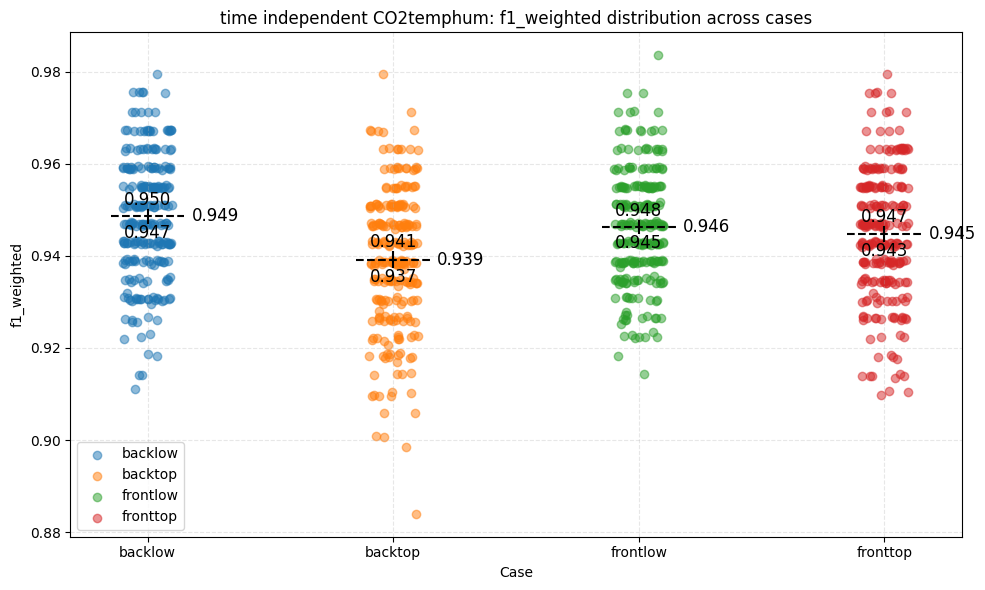

In [54]:
# plot f1 score
metric = "f1_weighted"

plt.figure(figsize=(10, 6))
for case in case_order:
    subset = df_metrics[df_metrics['case'] == case]
    plt.scatter(subset['x_jitter'], subset[metric], alpha=0.5, label=case)

for i, case in enumerate(case_order):
    vals = df_metrics[df_metrics['case'] == case][metric].values
    n = len(vals)
    mean_val = np.mean(vals)
    sem = stats.sem(vals)                  # standard error
    ci_low, ci_high = stats.t.interval(
        0.95, n - 1, loc=mean_val, scale=sem
    )
    plt.hlines(mean_val, i - 0.15, i + 0.15, colors='black', linestyles='dashed')
    plt.text(i + 0.18, mean_val, f"{mean_val:.3f}", va="center", ha="left", fontsize=12, color="black")
    plt.vlines(i, ci_low, ci_high, colors='black', linewidth=1.5)
    plt.text(i, ci_low, f"{ci_low:.3f}", va="top", ha="center", fontsize=12, color="black")
    plt.text(i, ci_high, f"{ci_high:.3f}", va="bottom", ha="center", fontsize=12, color="black")

plt.xticks(range(len(case_order)), case_order)
plt.xlabel("Case")
plt.ylabel(metric)
plt.title(f"{model}: {metric} distribution across cases")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

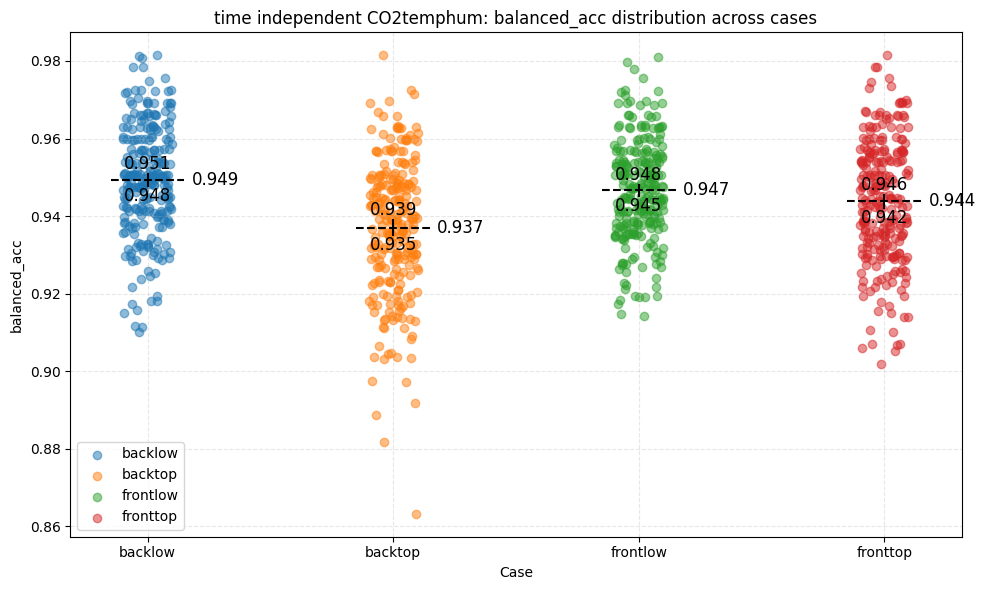

In [55]:
# plot balanced accuracy
metric = "balanced_acc"

plt.figure(figsize=(10, 6))
for case in case_order:
    subset = df_metrics[df_metrics['case'] == case]
    plt.scatter(subset['x_jitter'], subset[metric], alpha=0.5, label=case)

for i, case in enumerate(case_order):
    vals = df_metrics[df_metrics['case'] == case][metric].values
    n = len(vals)
    mean_val = np.mean(vals)
    sem = stats.sem(vals)                  # standard error
    ci_low, ci_high = stats.t.interval(
        0.95, n - 1, loc=mean_val, scale=sem
    )
    plt.hlines(mean_val, i - 0.15, i + 0.15, colors='black', linestyles='dashed')
    plt.text(i + 0.18, mean_val, f"{mean_val:.3f}", va="center", ha="left", fontsize=12, color="black")
    plt.vlines(i, ci_low, ci_high, colors='black', linewidth=1.5)
    plt.text(i, ci_low, f"{ci_low:.3f}", va="top", ha="center", fontsize=12, color="black")
    plt.text(i, ci_high, f"{ci_high:.3f}", va="bottom", ha="center", fontsize=12, color="black")

plt.xticks(range(len(case_order)), case_order)
plt.xlabel("Case")
plt.ylabel(metric)
plt.title(f"{model}: {metric} distribution across cases")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

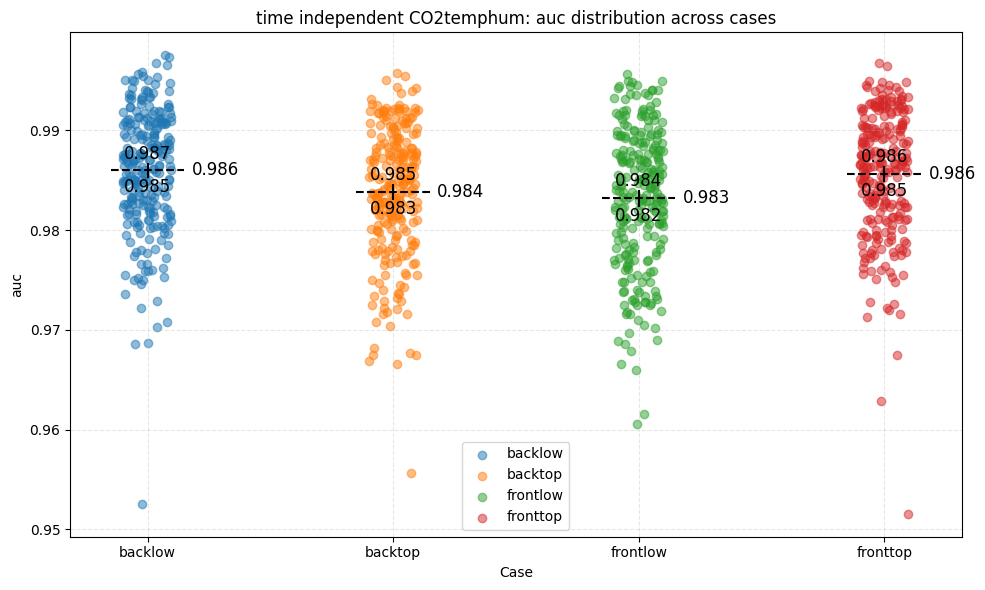

In [56]:
# plot auc
metric = "auc"

plt.figure(figsize=(10, 6))
for case in case_order:
    subset = df_metrics[df_metrics['case'] == case]
    plt.scatter(subset['x_jitter'], subset[metric], alpha=0.5, label=case)

for i, case in enumerate(case_order):
    vals = df_metrics[df_metrics['case'] == case][metric].values
    n = len(vals)
    mean_val = np.mean(vals)
    sem = stats.sem(vals)                  # standard error
    ci_low, ci_high = stats.t.interval(
        0.95, n - 1, loc=mean_val, scale=sem
    )
    plt.hlines(mean_val, i - 0.15, i + 0.15, colors='black', linestyles='dashed')
    plt.text(i + 0.18, mean_val, f"{mean_val:.3f}", va="center", ha="left", fontsize=12, color="black")
    plt.vlines(i, ci_low, ci_high, colors='black', linewidth=1.5)
    plt.text(i, ci_low, f"{ci_low:.3f}", va="top", ha="center", fontsize=12, color="black")
    plt.text(i, ci_high, f"{ci_high:.3f}", va="bottom", ha="center", fontsize=12, color="black")

plt.xticks(range(len(case_order)), case_order)
plt.xlabel("Case")
plt.ylabel(metric)
plt.title(f"{model}: {metric} distribution across cases")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

In [57]:
print(model)
check_anova_assumptions(
    df=df_metrics,
    group_col='case',
    metric_col='accuracy',
    group_order=case_order
)

time independent CO2temphum

=== Normality test (D’Agostino and Pearson) for accuracy ===
backlow                  :	p = 0.3184	→	OK normal
backtop                  :	p = 0.0176	→	not normal
frontlow                 :	p = 0.7555	→	OK normal
fronttop                 :	p = 0.4405	→	OK normal

=== Normality test (Shapiro-Wilk) for accuracy ===
backlow                  :	p = 0.0123	→	not normal
backtop                  :	p = 0.0057	→	not normal
frontlow                 :	p = 0.0392	→	not normal
fronttop                 :	p = 0.0145	→	not normal

=== Normality test (Anderson-Darling) for accuracy ===
backlow                  :	A² = 1.3060,	5% critical = 0.7750	→	not normal
backtop                  :	A² = 1.4762,	5% critical = 0.7750	→	not normal
frontlow                 :	A² = 1.2602,	5% critical = 0.7750	→	not normal
fronttop                 :	A² = 1.1852,	5% critical = 0.7750	→	not normal

=== Homogeneity of variance tests for accuracy ===
Levene’s test  : p = 0.0842	→	OK equal variances


In [58]:
print(model)
check_anova_assumptions(
    df=df_metrics,
    group_col='case',
    metric_col='f1_weighted',
    group_order=case_order
)

time independent CO2temphum

=== Normality test (D’Agostino and Pearson) for f1_weighted ===
backlow                  :	p = 0.3261	→	OK normal
backtop                  :	p = 0.0119	→	not normal
frontlow                 :	p = 0.7309	→	OK normal
fronttop                 :	p = 0.4548	→	OK normal

=== Normality test (Shapiro-Wilk) for f1_weighted ===
backlow                  :	p = 0.0441	→	not normal
backtop                  :	p = 0.0150	→	not normal
frontlow                 :	p = 0.1828	→	OK normal
fronttop                 :	p = 0.0453	→	not normal

=== Normality test (Anderson-Darling) for f1_weighted ===
backlow                  :	A² = 0.9413,	5% critical = 0.7750	→	not normal
backtop                  :	A² = 1.1023,	5% critical = 0.7750	→	not normal
frontlow                 :	A² = 0.8357,	5% critical = 0.7750	→	not normal
fronttop                 :	A² = 0.8523,	5% critical = 0.7750	→	not normal

=== Homogeneity of variance tests for f1_weighted ===
Levene’s test  : p = 0.0635	→	OK equal

In [59]:
print(model)
check_anova_assumptions(
    df=df_metrics,
    group_col='case',
    metric_col='balanced_acc',
    group_order=case_order
)

time independent CO2temphum

=== Normality test (D’Agostino and Pearson) for balanced_acc ===
backlow                  :	p = 0.3185	→	OK normal
backtop                  :	p = 0.0001	→	not normal
frontlow                 :	p = 0.9440	→	OK normal
fronttop                 :	p = 0.2641	→	OK normal

=== Normality test (Shapiro-Wilk) for balanced_acc ===
backlow                  :	p = 0.1106	→	OK normal
backtop                  :	p = 0.0021	→	not normal
frontlow                 :	p = 0.6969	→	OK normal
fronttop                 :	p = 0.2002	→	OK normal

=== Normality test (Anderson-Darling) for balanced_acc ===
backlow                  :	A² = 0.5207,	5% critical = 0.7750	→	OK normal
backtop                  :	A² = 0.8289,	5% critical = 0.7750	→	not normal
frontlow                 :	A² = 0.2464,	5% critical = 0.7750	→	OK normal
fronttop                 :	A² = 0.5013,	5% critical = 0.7750	→	OK normal

=== Homogeneity of variance tests for balanced_acc ===
Levene’s test  : p = 0.0002	→	unequal v

In [60]:
print(model)
check_anova_assumptions(
    df=df_metrics,
    group_col='case',
    metric_col='auc',
    group_order=case_order
)

time independent CO2temphum

=== Normality test (D’Agostino and Pearson) for auc ===
backlow                  :	p = 0.0000	→	not normal
backtop                  :	p = 0.0000	→	not normal
frontlow                 :	p = 0.0064	→	not normal
fronttop                 :	p = 0.0000	→	not normal

=== Normality test (Shapiro-Wilk) for auc ===
backlow                  :	p = 0.0000	→	not normal
backtop                  :	p = 0.0000	→	not normal
frontlow                 :	p = 0.0002	→	not normal
fronttop                 :	p = 0.0000	→	not normal

=== Normality test (Anderson-Darling) for auc ===
backlow                  :	A² = 1.3980,	5% critical = 0.7750	→	not normal
backtop                  :	A² = 1.8289,	5% critical = 0.7750	→	not normal
frontlow                 :	A² = 1.4242,	5% critical = 0.7750	→	not normal
fronttop                 :	A² = 2.2531,	5% critical = 0.7750	→	not normal

=== Homogeneity of variance tests for auc ===
Levene’s test  : p = 0.1250	→	OK equal variances
Bartlett’s test: 

### ANOVA

In [61]:
print(model)
run_anova_full(
    df=df_metrics,
    group_col='case',
    metric_col='accuracy'
)

time independent CO2temphum

=== Welch ANOVA for accuracy ===
Source  ddof1      ddof2         F        p-unc      np2
  case      3 552.051635 19.309223 6.425430e-12 0.059719

Effect size (partial η², np2) = 0.0597 → small effect

=== Games-Howell post-hoc test for accuracy ===
       A        B  mean(A)  mean(B)      diff       se         T         df         pval    hedges
 backlow  backtop 0.948198 0.938864  0.009333 0.001263  7.391163 491.760166 4.175549e-12  0.660090
 backlow frontlow 0.948198 0.945893  0.002305 0.001145  2.012891 494.872251 1.845625e-01  0.179767
 backlow fronttop 0.948198 0.944543  0.003654 0.001225  2.982329 496.354229 1.583358e-02  0.266346
 backtop frontlow 0.938864 0.945893 -0.007029 0.001221 -5.757488 480.571043 9.126088e-08 -0.514189
 backtop fronttop 0.938864 0.944543 -0.005679 0.001297 -4.380096 496.475047 8.518765e-05 -0.391177
frontlow fronttop 0.945893 0.944543  0.001350 0.001182  1.141921 488.896363 6.637202e-01  0.101983

=== Pairwise effect sizes 

In [62]:
print(model)
run_anova_full(
    df=df_metrics,
    group_col='case',
    metric_col='f1_weighted'
)

time independent CO2temphum

=== Welch ANOVA for f1_weighted ===
Source  ddof1      ddof2         F        p-unc      np2
  case      3 551.945263 19.865018 3.063016e-12 0.061538

Effect size (partial η², np2) = 0.0615 → medium effect

=== Games-Howell post-hoc test for f1_weighted ===
       A        B  mean(A)  mean(B)      diff       se         T         df         pval    hedges
 backlow  backtop 0.948544 0.939143  0.009401 0.001254  7.495803 490.909007 2.240208e-12  0.669435
 backlow frontlow 0.948544 0.946247  0.002297 0.001132  2.029093 494.818488 1.786792e-01  0.181214
 backlow fronttop 0.948544 0.944836  0.003708 0.001214  3.054744 496.153261 1.265763e-02  0.272813
 backtop frontlow 0.939143 0.946247 -0.007104 0.001213 -5.859113 479.129160 5.187615e-08 -0.523265
 backtop fronttop 0.939143 0.944836 -0.005693 0.001290 -4.414461 496.236476 7.323101e-05 -0.394246
frontlow fronttop 0.946247 0.944836  0.001412 0.001171  1.205687 488.358730 6.235184e-01  0.107677

=== Pairwise effect

In [63]:
print(model)
run_anova_full(
    df=df_metrics,
    group_col='case',
    metric_col='balanced_acc'
)

time independent CO2temphum

=== Welch ANOVA for balanced_acc ===
Source  ddof1      ddof2         F        p-unc      np2
  case      3 550.384498 26.947495 2.835184e-16 0.083871

Effect size (partial η², np2) = 0.0839 → medium effect

=== Games-Howell post-hoc test for balanced_acc ===
       A        B  mean(A)  mean(B)      diff       se         T         df         pval    hedges
 backlow  backtop 0.949329 0.936983  0.012346 0.001427  8.654148 478.252517 1.235678e-13  0.772884
 backlow frontlow 0.949329 0.946655  0.002675 0.001219  2.193544 493.926216 1.264192e-01  0.195901
 backlow fronttop 0.949329 0.943826  0.005504 0.001345  4.091688 492.707045 2.912993e-04  0.365420
 backtop frontlow 0.936983 0.946655 -0.009672 0.001379 -7.016104 459.688358 4.932543e-11 -0.626594
 backtop fronttop 0.936983 0.943826 -0.006843 0.001491 -4.589599 492.902268 3.337319e-05 -0.409888
frontlow fronttop 0.946655 0.943826  0.002829 0.001294  2.186424 480.178587 1.284513e-01  0.195265

=== Pairwise effe

In [64]:
print(model)
run_anova_full(
    df=df_metrics,
    group_col='case',
    metric_col='auc'
)

time independent CO2temphum

=== Welch ANOVA for auc ===
Source  ddof1      ddof2         F        p-unc      np2
  case      3 552.859836 10.612082 8.578372e-07 0.031464

Effect size (partial η², np2) = 0.0315 → small effect

=== Games-Howell post-hoc test for auc ===
       A        B  mean(A)  mean(B)      diff       se         T         df     pval    hedges
 backlow  backtop 0.985987 0.983858  0.002129 0.000565  3.766199 496.758069 0.001062  0.336352
 backlow frontlow 0.985987 0.983198  0.002789 0.000588  4.742504 490.627963 0.000016  0.423543
 backlow fronttop 0.985987 0.985620  0.000367 0.000560  0.654682 497.483734 0.913886  0.058468
 backtop frontlow 0.983858 0.983198  0.000661 0.000602  1.097963 495.358334 0.690950  0.098057
 backtop fronttop 0.983858 0.985620 -0.001762 0.000574 -3.069408 497.841994 0.012087 -0.274123
frontlow fronttop 0.983198 0.985620 -0.002423 0.000597 -4.060270 493.934549 0.000331 -0.362614

=== Pairwise effect sizes for auc (Hedges' g) ===
backlow    vs 

## Time series - CO2temphum

In [65]:
model = "time series CO2temphum"
backlow = pd.read_csv("../_timeseries_results_raw/case_room1_backlow_state_timeseries_co2temphum.csv")
backtop = pd.read_csv("../_timeseries_results_raw/case_room1_backtop_state_timeseries_co2temphum.csv")
frontlow = pd.read_csv("../_timeseries_results_raw/case_room1_frontlow_state_timeseries_co2temphum.csv")
fronttop = pd.read_csv("../_timeseries_results_raw/case_room1_fronttop_state_timeseries_co2temphum.csv")

In [66]:
backlow.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
random_seed,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
accuracy,250.0,0.817742,0.052034,0.582222,0.796667,0.826667,0.848889,0.920000
f1,250.0,0.755069,0.065840,0.460317,0.713376,0.762500,0.797619,0.902174
balanced_acc,250.0,0.798093,0.052121,0.608083,0.770513,0.804797,0.830296,0.917252
auc,250.0,0.895276,0.040989,0.720824,0.875020,0.906424,0.923096,0.956930
feature_importance.backlow_CO2_scaled,250.0,0.088658,0.101909,-0.025778,0.013444,0.046889,0.143889,0.419111
feature_importance.backlow_CO2_fd1_scaled,250.0,0.001531,0.025967,-0.082667,-0.012000,0.000667,0.014556,0.093333
feature_importance.backlow_CO2_fd2_scaled,250.0,-0.001790,0.025868,-0.079556,-0.016444,-0.000889,0.012778,0.067556
feature_importance.backlow_CO2_fd3_scaled,250.0,-0.007973,0.026893,-0.094667,-0.023333,-0.005778,0.008000,0.067111


In [67]:
backtop.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
random_seed,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
accuracy,250.0,0.819869,0.034056,0.694836,0.798122,0.821596,0.845070,0.910798
f1,250.0,0.761014,0.054995,0.595745,0.726115,0.765432,0.802395,0.893855
balanced_acc,250.0,0.802253,0.039172,0.688421,0.775748,0.803899,0.831073,0.905857
auc,250.0,0.901399,0.035888,0.744071,0.882097,0.914481,0.927484,0.956701
feature_importance.backtop_CO2_scaled,250.0,0.049837,0.056606,-0.021596,0.013146,0.034038,0.067254,0.322066
feature_importance.backtop_CO2_fd1_scaled,250.0,-0.008633,0.025631,-0.070423,-0.026174,-0.006103,0.007981,0.084977
feature_importance.backtop_CO2_fd2_scaled,250.0,-0.007983,0.026365,-0.092488,-0.023474,-0.007277,0.009742,0.075587
feature_importance.backtop_CO2_fd3_scaled,250.0,-0.014732,0.027402,-0.089671,-0.032394,-0.012207,0.003286,0.063380


In [68]:
frontlow.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
random_seed,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
accuracy,250.0,0.843767,0.021085,0.725000,0.833333,0.845833,0.854167,0.904167
f1,250.0,0.771533,0.033965,0.496124,0.753086,0.772579,0.792314,0.870056
balanced_acc,250.0,0.814865,0.023900,0.657021,0.801116,0.814997,0.829612,0.891451
auc,250.0,0.904463,0.023938,0.834166,0.886971,0.910326,0.922665,0.948737
feature_importance.frontlow_CO2_scaled,250.0,0.052462,0.058610,-0.022500,0.004687,0.028333,0.092708,0.222917
feature_importance.frontlow_CO2_fd1_scaled,250.0,0.003340,0.009532,-0.020000,-0.002083,0.001250,0.006667,0.046250
feature_importance.frontlow_CO2_fd2_scaled,250.0,0.004125,0.009204,-0.018750,-0.001250,0.002917,0.008750,0.047917
feature_importance.frontlow_CO2_fd3_scaled,250.0,0.003527,0.009777,-0.027083,-0.002500,0.002500,0.009167,0.037917


In [69]:
fronttop.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,1.867500e+02,249.000000
random_seed,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,1.867500e+02,249.000000
accuracy,250.0,0.881150,0.012829,0.804167,0.875000,0.879167,8.875000e-01,0.920833
f1,250.0,0.834427,0.022847,0.680272,0.825581,0.834286,8.457143e-01,0.896175
balanced_acc,250.0,0.862828,0.017711,0.754847,0.855464,0.862221,8.717685e-01,0.915247
auc,250.0,0.944755,0.024562,0.854363,0.931918,0.949581,9.634805e-01,0.978187
feature_importance.fronttop_CO2_scaled,250.0,0.116800,0.065490,-0.015000,0.075208,0.117708,1.666667e-01,0.276250
feature_importance.fronttop_CO2_fd1_scaled,250.0,-0.003193,0.008051,-0.023333,-0.007813,-0.003333,4.166667e-04,0.041250
feature_importance.fronttop_CO2_fd2_scaled,250.0,-0.002492,0.007328,-0.026250,-0.006250,-0.001667,1.666667e-03,0.032083
feature_importance.fronttop_CO2_fd3_scaled,250.0,0.001300,0.007086,-0.019583,-0.002500,0.001250,4.583333e-03,0.037917


In [71]:
backlow['case'] = 'backlow'
backtop['case'] = 'backtop'
frontlow['case'] = 'frontlow'
fronttop['case'] = 'fronttop'

metrics = ["case", "accuracy", "f1", "balanced_acc", "auc"]

df_metrics = pd.concat(
    [
        backlow[metrics],
        backtop[metrics],
        frontlow[metrics],
        fronttop[metrics]
    ],
    ignore_index=True
)

df_metrics.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   case          1000 non-null   object 
 1   accuracy      1000 non-null   float64
 2   f1            1000 non-null   float64
 3   balanced_acc  1000 non-null   float64
 4   auc           1000 non-null   float64
dtypes: float64(4), object(1)
memory usage: 39.2+ KB


In [72]:
case_order = ['backlow', 'backtop', 'frontlow', 'fronttop']
df_metrics['x'] = df_metrics['case'].map({name: i for i, name in enumerate(case_order)})
df_metrics['x_jitter'] = df_metrics['x'] + np.random.uniform(-0.1, 0.1, size=len(df_metrics))

df_metrics.head().T

,0,1,2,3,4
case,backlow,backlow,backlow,backlow,backlow
accuracy,0.835556,0.871111,0.88,0.8,0.848889
f1,0.773006,0.834286,0.855615,0.713376,0.797619
balanced_acc,0.812316,0.859145,0.878392,0.770513,0.830296
auc,0.931432,0.920807,0.908385,0.857306,0.943282
x,0,0,0,0,0
x_jitter,-0.035246,-0.093547,-0.098259,-0.067993,-0.060972


### plot

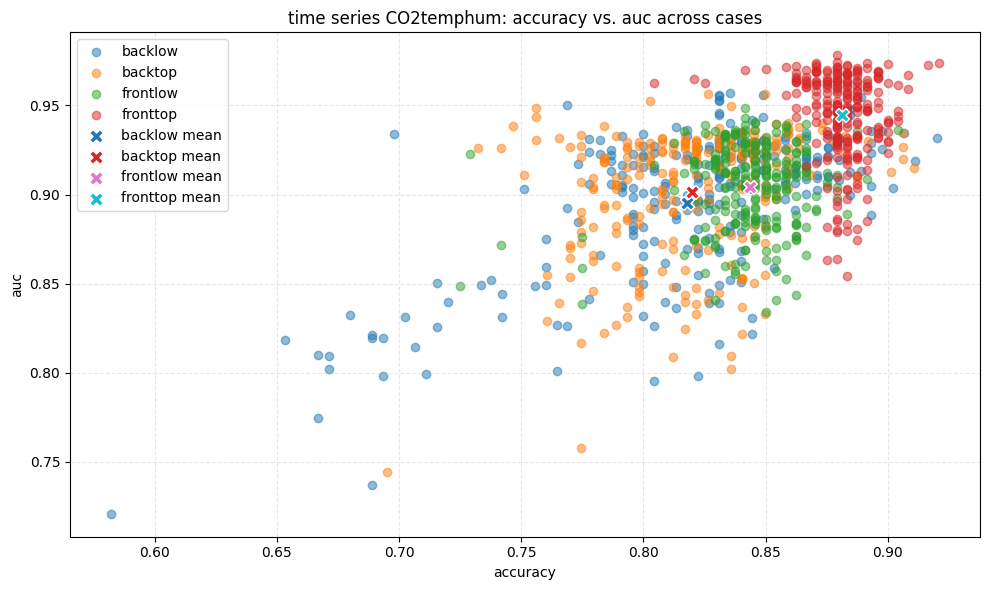

In [73]:
# plot metrics
metrics_plot = ["accuracy", "auc"]

colors = plt.cm.tab10(np.linspace(0, 1, len(case_order)))
case_color_map = {case: color for case, color in zip(case_order, colors)}
plt.figure(figsize=(10, 6))

for case in case_order:
    subset = df_metrics[df_metrics['case'] == case]
    plt.scatter(subset[metrics_plot[0]], subset[metrics_plot[1]], alpha=0.5, label=case)

# average
for case in case_order:
    subset = df_metrics[df_metrics['case'] == case]
    mean_x = subset[metrics_plot[0]].mean()
    mean_y = subset[metrics_plot[1]].mean()
    plt.scatter(mean_x, mean_y, marker='X', color=case_color_map[case], edgecolor='white', s=100, label=f'{case} mean')

plt.xlabel(f"{metrics_plot[0]}")
plt.ylabel(f"{metrics_plot[1]}")
plt.title(f"{model}: {metrics_plot[0]} vs. {metrics_plot[1]} across cases")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

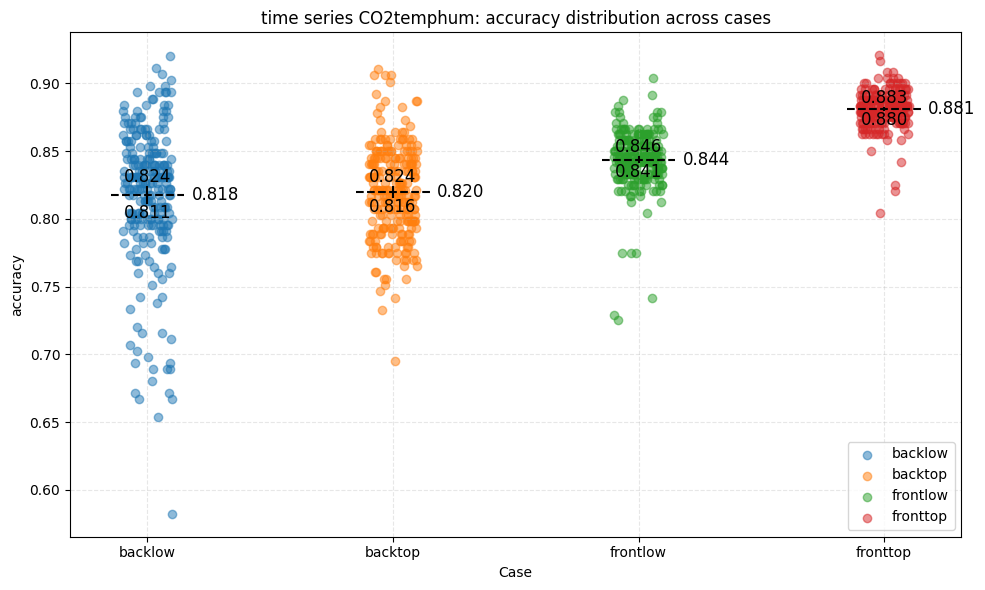

In [74]:
# plot accuracy
metric = "accuracy"

plt.figure(figsize=(10, 6))
for case in case_order:
    subset = df_metrics[df_metrics['case'] == case]
    plt.scatter(subset['x_jitter'], subset[metric], alpha=0.5, label=case)

for i, case in enumerate(case_order):
    vals = df_metrics[df_metrics['case'] == case][metric].values
    n = len(vals)
    mean_val = np.mean(vals)
    sem = stats.sem(vals)                  # standard error
    ci_low, ci_high = stats.t.interval(
        0.95, n - 1, loc=mean_val, scale=sem
    )
    plt.hlines(mean_val, i - 0.15, i + 0.15, colors='black', linestyles='dashed')
    plt.text(i + 0.18, mean_val, f"{mean_val:.3f}", va="center", ha="left", fontsize=12, color="black")
    plt.vlines(i, ci_low, ci_high, colors='black', linewidth=1.5)
    plt.text(i, ci_low, f"{ci_low:.3f}", va="top", ha="center", fontsize=12, color="black")
    plt.text(i, ci_high, f"{ci_high:.3f}", va="bottom", ha="center", fontsize=12, color="black")

plt.xticks(range(len(case_order)), case_order)
plt.xlabel("Case")
plt.ylabel(metric)
plt.title(f"{model}: {metric} distribution across cases")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

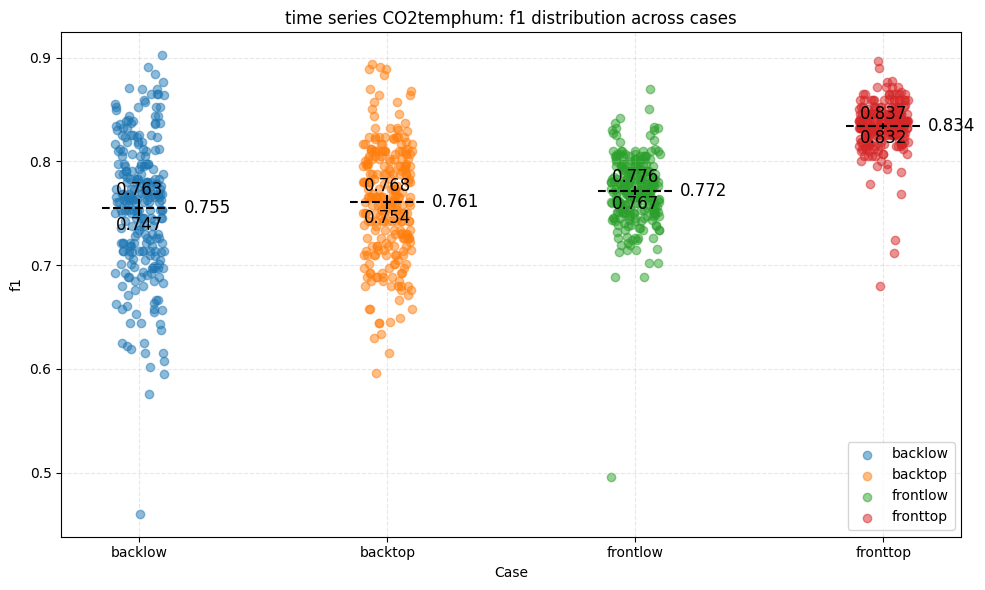

In [75]:
# plot f1 score
metric = "f1"

plt.figure(figsize=(10, 6))
for case in case_order:
    subset = df_metrics[df_metrics['case'] == case]
    plt.scatter(subset['x_jitter'], subset[metric], alpha=0.5, label=case)

for i, case in enumerate(case_order):
    vals = df_metrics[df_metrics['case'] == case][metric].values
    n = len(vals)
    mean_val = np.mean(vals)
    sem = stats.sem(vals)                  # standard error
    ci_low, ci_high = stats.t.interval(
        0.95, n - 1, loc=mean_val, scale=sem
    )
    plt.hlines(mean_val, i - 0.15, i + 0.15, colors='black', linestyles='dashed')
    plt.text(i + 0.18, mean_val, f"{mean_val:.3f}", va="center", ha="left", fontsize=12, color="black")
    plt.vlines(i, ci_low, ci_high, colors='black', linewidth=1.5)
    plt.text(i, ci_low, f"{ci_low:.3f}", va="top", ha="center", fontsize=12, color="black")
    plt.text(i, ci_high, f"{ci_high:.3f}", va="bottom", ha="center", fontsize=12, color="black")

plt.xticks(range(len(case_order)), case_order)
plt.xlabel("Case")
plt.ylabel(metric)
plt.title(f"{model}: {metric} distribution across cases")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

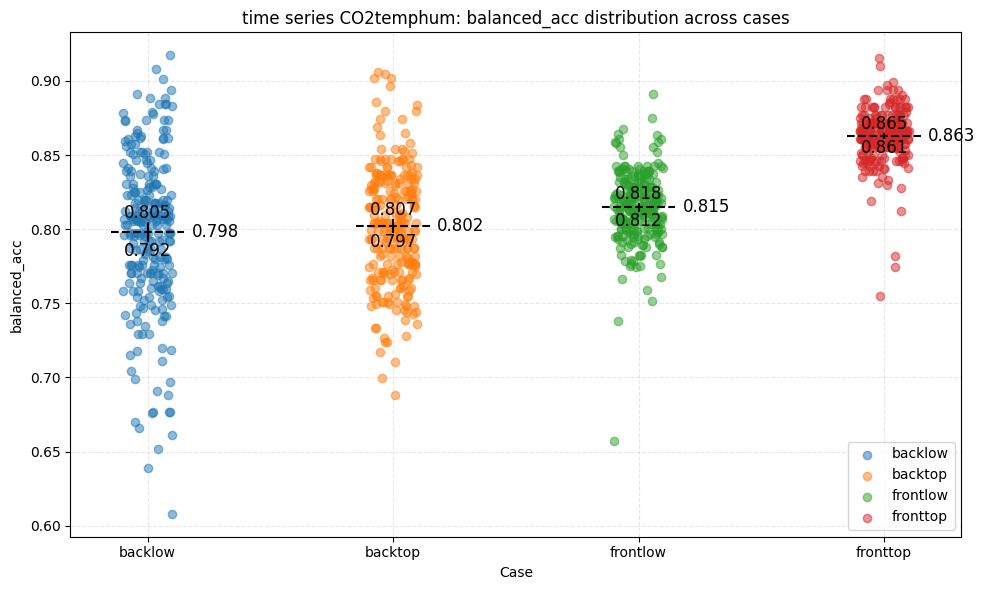

In [76]:
# plot balanced accuracy
metric = "balanced_acc"

plt.figure(figsize=(10, 6))
for case in case_order:
    subset = df_metrics[df_metrics['case'] == case]
    plt.scatter(subset['x_jitter'], subset[metric], alpha=0.5, label=case)

for i, case in enumerate(case_order):
    vals = df_metrics[df_metrics['case'] == case][metric].values
    n = len(vals)
    mean_val = np.mean(vals)
    sem = stats.sem(vals)                  # standard error
    ci_low, ci_high = stats.t.interval(
        0.95, n - 1, loc=mean_val, scale=sem
    )
    plt.hlines(mean_val, i - 0.15, i + 0.15, colors='black', linestyles='dashed')
    plt.text(i + 0.18, mean_val, f"{mean_val:.3f}", va="center", ha="left", fontsize=12, color="black")
    plt.vlines(i, ci_low, ci_high, colors='black', linewidth=1.5)
    plt.text(i, ci_low, f"{ci_low:.3f}", va="top", ha="center", fontsize=12, color="black")
    plt.text(i, ci_high, f"{ci_high:.3f}", va="bottom", ha="center", fontsize=12, color="black")

plt.xticks(range(len(case_order)), case_order)
plt.xlabel("Case")
plt.ylabel(metric)
plt.title(f"{model}: {metric} distribution across cases")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

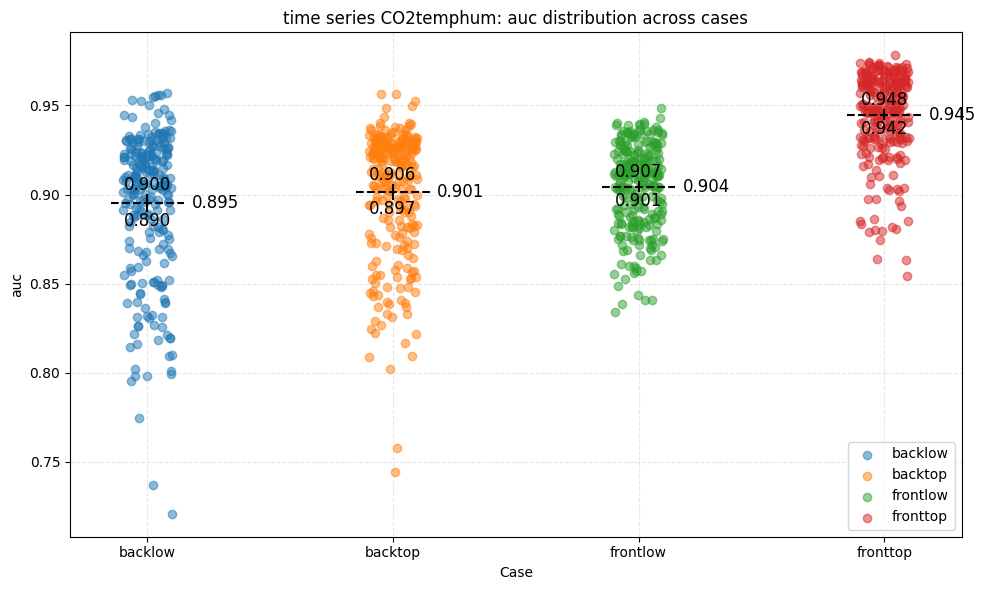

In [77]:
# plot auc
metric = "auc"

plt.figure(figsize=(10, 6))
for case in case_order:
    subset = df_metrics[df_metrics['case'] == case]
    plt.scatter(subset['x_jitter'], subset[metric], alpha=0.5, label=case)

for i, case in enumerate(case_order):
    vals = df_metrics[df_metrics['case'] == case][metric].values
    n = len(vals)
    mean_val = np.mean(vals)
    sem = stats.sem(vals)                  # standard error
    ci_low, ci_high = stats.t.interval(
        0.95, n - 1, loc=mean_val, scale=sem
    )
    plt.hlines(mean_val, i - 0.15, i + 0.15, colors='black', linestyles='dashed')
    plt.text(i + 0.18, mean_val, f"{mean_val:.3f}", va="center", ha="left", fontsize=12, color="black")
    plt.vlines(i, ci_low, ci_high, colors='black', linewidth=1.5)
    plt.text(i, ci_low, f"{ci_low:.3f}", va="top", ha="center", fontsize=12, color="black")
    plt.text(i, ci_high, f"{ci_high:.3f}", va="bottom", ha="center", fontsize=12, color="black")

plt.xticks(range(len(case_order)), case_order)
plt.xlabel("Case")
plt.ylabel(metric)
plt.title(f"{model}: {metric} distribution across cases")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

In [78]:
print(model)
check_anova_assumptions(
    df=df_metrics,
    group_col='case',
    metric_col='accuracy',
    group_order=case_order
)

time series CO2temphum

=== Normality test (D’Agostino and Pearson) for accuracy ===
backlow                  :	p = 0.0000	→	not normal
backtop                  :	p = 0.4476	→	OK normal
frontlow                 :	p = 0.0000	→	not normal
fronttop                 :	p = 0.0000	→	not normal

=== Normality test (Shapiro-Wilk) for accuracy ===
backlow                  :	p = 0.0000	→	not normal
backtop                  :	p = 0.1266	→	OK normal
frontlow                 :	p = 0.0000	→	not normal
fronttop                 :	p = 0.0000	→	not normal

=== Normality test (Anderson-Darling) for accuracy ===
backlow                  :	A² = 5.6805,	5% critical = 0.7750	→	not normal
backtop                  :	A² = 0.6268,	5% critical = 0.7750	→	OK normal
frontlow                 :	A² = 6.0583,	5% critical = 0.7750	→	not normal
fronttop                 :	A² = 5.6321,	5% critical = 0.7750	→	not normal

=== Homogeneity of variance tests for accuracy ===
Levene’s test  : p = 0.0000	→	unequal variances
Bartle

In [79]:
print(model)
check_anova_assumptions(
    df=df_metrics,
    group_col='case',
    metric_col='f1',
    group_order=case_order
)

time series CO2temphum

=== Normality test (D’Agostino and Pearson) for f1 ===
backlow                  :	p = 0.0001	→	not normal
backtop                  :	p = 0.4478	→	OK normal
frontlow                 :	p = 0.0000	→	not normal
fronttop                 :	p = 0.0000	→	not normal

=== Normality test (Shapiro-Wilk) for f1 ===
backlow                  :	p = 0.0019	→	not normal
backtop                  :	p = 0.1871	→	OK normal
frontlow                 :	p = 0.0000	→	not normal
fronttop                 :	p = 0.0000	→	not normal

=== Normality test (Anderson-Darling) for f1 ===
backlow                  :	A² = 0.7165,	5% critical = 0.7750	→	OK normal
backtop                  :	A² = 0.6953,	5% critical = 0.7750	→	OK normal
frontlow                 :	A² = 2.1048,	5% critical = 0.7750	→	not normal
fronttop                 :	A² = 7.0428,	5% critical = 0.7750	→	not normal

=== Homogeneity of variance tests for f1 ===
Levene’s test  : p = 0.0000	→	unequal variances
Bartlett’s test: p = 0.0000	→	u

In [80]:
print(model)
check_anova_assumptions(
    df=df_metrics,
    group_col='case',
    metric_col='balanced_acc',
    group_order=case_order
)

time series CO2temphum

=== Normality test (D’Agostino and Pearson) for balanced_acc ===
backlow                  :	p = 0.0001	→	not normal
backtop                  :	p = 0.9643	→	OK normal
frontlow                 :	p = 0.0000	→	not normal
fronttop                 :	p = 0.0000	→	not normal

=== Normality test (Shapiro-Wilk) for balanced_acc ===
backlow                  :	p = 0.0002	→	not normal
backtop                  :	p = 0.3676	→	OK normal
frontlow                 :	p = 0.0000	→	not normal
fronttop                 :	p = 0.0000	→	not normal

=== Normality test (Anderson-Darling) for balanced_acc ===
backlow                  :	A² = 1.4590,	5% critical = 0.7750	→	not normal
backtop                  :	A² = 0.4876,	5% critical = 0.7750	→	OK normal
frontlow                 :	A² = 1.5111,	5% critical = 0.7750	→	not normal
fronttop                 :	A² = 5.5435,	5% critical = 0.7750	→	not normal

=== Homogeneity of variance tests for balanced_acc ===
Levene’s test  : p = 0.0000	→	unequal 

In [81]:
print(model)
check_anova_assumptions(
    df=df_metrics,
    group_col='case',
    metric_col='auc',
    group_order=case_order
)

time series CO2temphum

=== Normality test (D’Agostino and Pearson) for auc ===
backlow                  :	p = 0.0000	→	not normal
backtop                  :	p = 0.0000	→	not normal
frontlow                 :	p = 0.0005	→	not normal
fronttop                 :	p = 0.0000	→	not normal

=== Normality test (Shapiro-Wilk) for auc ===
backlow                  :	p = 0.0000	→	not normal
backtop                  :	p = 0.0000	→	not normal
frontlow                 :	p = 0.0000	→	not normal
fronttop                 :	p = 0.0000	→	not normal

=== Normality test (Anderson-Darling) for auc ===
backlow                  :	A² = 8.6079,	5% critical = 0.7750	→	not normal
backtop                  :	A² = 10.5894,	5% critical = 0.7750	→	not normal
frontlow                 :	A² = 2.9332,	5% critical = 0.7750	→	not normal
fronttop                 :	A² = 7.5302,	5% critical = 0.7750	→	not normal

=== Homogeneity of variance tests for auc ===
Levene’s test  : p = 0.0000	→	unequal variances
Bartlett’s test: p = 0

### ANOVA

In [82]:
print(model)
run_anova_full(
    df=df_metrics,
    group_col='case',
    metric_col='accuracy'
)

time series CO2temphum

=== Welch ANOVA for accuracy ===
Source  ddof1      ddof2          F         p-unc      np2
  case      3 504.201555 430.215535 1.473365e-138 0.368936

Effect size (partial η², np2) = 0.3689 → large effect

=== Games-Howell post-hoc test for accuracy ===
       A        B  mean(A)  mean(B)      diff       se          T         df         pval    hedges
 backlow  backtop 0.817742 0.819869 -0.002126 0.003933  -0.540622 429.249899 9.490206e-01 -0.048282
 backlow frontlow 0.817742 0.843767 -0.026024 0.003551  -7.329102 328.627462 1.085654e-11 -0.654547
 backlow fronttop 0.817742 0.881150 -0.063408 0.003389 -18.707397 279.158638 1.239009e-13 -1.670719
 backtop frontlow 0.819869 0.843767 -0.023898 0.002533  -9.433622 415.442198 2.345901e-13 -0.842497
 backtop fronttop 0.819869 0.881150 -0.061281 0.002302 -26.625256 318.269765 0.000000e+00 -2.377847
frontlow fronttop 0.843767 0.881150 -0.037383 0.001561 -23.948673 411.127180 0.000000e+00 -2.138807

=== Pairwise effect 

In [83]:
print(model)
run_anova_full(
    df=df_metrics,
    group_col='case',
    metric_col='f1'
)

time series CO2temphum

=== Welch ANOVA for f1 ===
Source  ddof1     ddof2          F         p-unc      np2
  case      3 516.60674 319.521225 2.895750e-117 0.308517

Effect size (partial η², np2) = 0.3085 → large effect

=== Games-Howell post-hoc test for f1 ===
       A        B  mean(A)  mean(B)      diff       se          T         df         pval    hedges
 backlow  backtop 0.755069 0.761014 -0.005945 0.005426  -1.095716 482.694665 6.923331e-01 -0.097856
 backlow frontlow 0.755069 0.771533 -0.016465 0.004686  -3.513942 372.763705 2.779884e-03 -0.313823
 backlow fronttop 0.755069 0.834427 -0.079359 0.004408 -18.004564 308.109819 2.597922e-14 -1.607951
 backtop frontlow 0.761014 0.771533 -0.010520 0.004088  -2.573274 414.826316 5.081811e-02 -0.229814
 backtop fronttop 0.761014 0.834427 -0.073414 0.003766 -19.491658 332.463819 5.095924e-14 -1.740760
frontlow fronttop 0.771533 0.834427 -0.062894 0.002589 -24.293537 436.041272 7.960299e-14 -2.169606

=== Pairwise effect sizes for f1 (

In [84]:
print(model)
run_anova_full(
    df=df_metrics,
    group_col='case',
    metric_col='balanced_acc'
)

time series CO2temphum

=== Welch ANOVA for balanced_acc ===
Source  ddof1    ddof2          F         p-unc     np2
  case      3 521.2776 359.166399 2.079779e-126 0.34164

Effect size (partial η², np2) = 0.3416 → large effect

=== Games-Howell post-hoc test for balanced_acc ===
       A        B  mean(A)  mean(B)      diff       se          T         df         pval    hedges
 backlow  backtop 0.798093 0.802253 -0.004160 0.004124  -1.008856 462.255492 7.443251e-01 -0.090099
 backlow frontlow 0.798093 0.814865 -0.016772 0.003626  -4.624913 349.281877 3.125407e-05 -0.413041
 backlow fronttop 0.798093 0.862828 -0.064735 0.003482 -18.593856 305.748596 2.728928e-13 -1.660579
 backtop frontlow 0.802253 0.814865 -0.012612 0.002902  -4.345647 411.822513 1.028710e-04 -0.388101
 backtop fronttop 0.802253 0.862828 -0.060575 0.002719 -22.278924 346.721961 1.779688e-13 -1.989685
frontlow fronttop 0.814865 0.862828 -0.047963 0.001881 -25.493350 459.114795 5.973000e-14 -2.276759

=== Pairwise effec

In [85]:
print(model)
run_anova_full(
    df=df_metrics,
    group_col='case',
    metric_col='auc'
)

time series CO2temphum

=== Welch ANOVA for auc ===
Source  ddof1      ddof2          F        p-unc      np2
  case      3 542.216679 167.992948 5.329937e-77 0.269218

Effect size (partial η², np2) = 0.2692 → large effect

=== Games-Howell post-hoc test for auc ===
       A        B  mean(A)  mean(B)      diff       se          T         df         pval    hedges
 backlow  backtop 0.895276 0.901399 -0.006123 0.003446  -1.777135 489.453976 2.855955e-01 -0.158712
 backlow frontlow 0.895276 0.904463 -0.009187 0.003002  -3.060208 401.154884 1.258108e-02 -0.273301
 backlow fronttop 0.895276 0.944755 -0.049479 0.003022 -16.371980 407.399480 3.446132e-13 -1.462148
 backtop frontlow 0.901399 0.904463 -0.003064 0.002728  -1.122940 433.961843 6.755627e-01 -0.100287
 backtop fronttop 0.901399 0.944755 -0.043356 0.002750 -15.763319 440.301281 0.000000e+00 -1.407790
frontlow fronttop 0.904463 0.944755 -0.040292 0.002169 -18.574788 497.670763 0.000000e+00 -1.658876

=== Pairwise effect sizes for au

## Time independent - temphum

In [86]:
model = "time independent temphum"
backlow = pd.read_csv("../_timeindep_results_raw/case_room1_backlow_state_timeindep_temphum.csv")
backtop = pd.read_csv("../_timeindep_results_raw/case_room1_backtop_state_timeindep_temphum.csv")
frontlow = pd.read_csv("../_timeindep_results_raw/case_room1_frontlow_state_timeindep_temphum.csv")
fronttop = pd.read_csv("../_timeindep_results_raw/case_room1_fronttop_state_timeindep_temphum.csv")

In [87]:
backlow.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
random_seed,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
accuracy,250.0,0.925580,0.016803,0.880658,0.913580,0.925926,0.938272,0.967078
f1_weighted,250.0,0.925917,0.016726,0.880286,0.914107,0.926303,0.938356,0.967078
balanced_acc,250.0,0.922119,0.018983,0.869325,0.910129,0.924711,0.934418,0.963386
auc,250.0,0.976960,0.008265,0.949045,0.971728,0.978061,0.983239,0.993410
model_weights.random_forest,250.0,1.412710,0.388093,0.247031,1.154504,1.394853,1.707664,2.407252
model_weights.bagging_svc,250.0,0.820873,0.306317,-0.027893,0.594161,0.824544,1.057518,1.630331
model_weights.bagging_knn,250.0,1.707368,0.350114,0.294897,1.485212,1.736976,1.960199,2.733994
model_weights.gradient_boosting,250.0,2.276132,0.379534,0.924856,2.010198,2.266144,2.529144,3.494664


In [88]:
backtop.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
random_seed,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
accuracy,250.0,0.923918,0.016630,0.876543,0.913580,0.925926,0.934156,0.971193
f1_weighted,250.0,0.924276,0.016568,0.876543,0.914032,0.925734,0.934392,0.971155
balanced_acc,250.0,0.920624,0.019009,0.862243,0.908788,0.920972,0.933021,0.974522
auc,250.0,0.974933,0.008571,0.947432,0.969257,0.975735,0.980860,0.996889
model_weights.random_forest,250.0,1.945160,0.449133,0.473042,1.639918,1.976667,2.260804,3.227916
model_weights.bagging_svc,250.0,0.679337,0.364903,-0.320406,0.454267,0.666219,0.925826,1.612781
model_weights.bagging_knn,250.0,1.184415,0.381133,-0.224493,0.933923,1.172778,1.427794,2.288332
model_weights.gradient_boosting,250.0,2.726937,0.397722,1.652260,2.475704,2.721621,2.994472,3.815552


In [89]:
frontlow.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
random_seed,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
accuracy,250.0,0.935868,0.015848,0.888889,0.925926,0.938272,0.946502,0.975309
f1_weighted,250.0,0.936242,0.015760,0.888555,0.926209,0.938095,0.946786,0.975309
balanced_acc,250.0,0.935029,0.017978,0.872508,0.924634,0.936644,0.947373,0.973004
auc,250.0,0.977424,0.008474,0.953340,0.971877,0.978292,0.983677,0.995408
model_weights.random_forest,250.0,2.139931,0.465908,0.889133,1.778921,2.171690,2.464986,3.316495
model_weights.bagging_svc,250.0,0.753868,0.282191,0.158516,0.537447,0.765822,0.968776,1.651931
model_weights.bagging_knn,250.0,1.659841,0.372627,0.664565,1.452134,1.663437,1.871034,2.689184
model_weights.gradient_boosting,250.0,2.077209,0.375805,0.912339,1.827648,2.087590,2.325576,3.301072


In [90]:
fronttop.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
random_seed,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
accuracy,250.0,0.928263,0.016142,0.880658,0.917695,0.930041,0.938272,0.975309
f1_weighted,250.0,0.928734,0.016001,0.881061,0.918421,0.930048,0.938687,0.975371
balanced_acc,250.0,0.927354,0.017977,0.875018,0.915836,0.927625,0.938315,0.975633
auc,250.0,0.976850,0.007787,0.954477,0.971795,0.977400,0.983067,0.991214
model_weights.random_forest,250.0,2.051162,0.459004,0.990083,1.730693,2.006081,2.402884,3.267723
model_weights.bagging_svc,250.0,0.815666,0.236958,0.144473,0.653270,0.836941,0.993394,1.430464
model_weights.bagging_knn,250.0,1.854286,0.347427,0.942866,1.640030,1.895608,2.095599,2.791238
model_weights.gradient_boosting,250.0,1.636671,0.364534,0.621749,1.390755,1.632230,1.851720,2.640657


In [91]:
backlow['case'] = 'backlow'
backtop['case'] = 'backtop'
frontlow['case'] = 'frontlow'
fronttop['case'] = 'fronttop'

metrics = ["case", "accuracy", "f1_weighted", "balanced_acc", "auc"]

df_metrics = pd.concat(
    [
        backlow[metrics],
        backtop[metrics],
        frontlow[metrics],
        fronttop[metrics]
    ],
    ignore_index=True
)

df_metrics.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   case          1000 non-null   object 
 1   accuracy      1000 non-null   float64
 2   f1_weighted   1000 non-null   float64
 3   balanced_acc  1000 non-null   float64
 4   auc           1000 non-null   float64
dtypes: float64(4), object(1)
memory usage: 39.2+ KB


In [92]:
case_order = ['backlow', 'backtop', 'frontlow', 'fronttop']
df_metrics['x'] = df_metrics['case'].map({name: i for i, name in enumerate(case_order)})
df_metrics['x_jitter'] = df_metrics['x'] + np.random.uniform(-0.1, 0.1, size=len(df_metrics))

df_metrics.head().T

,0,1,2,3,4
case,backlow,backlow,backlow,backlow,backlow
accuracy,0.909465,0.930041,0.921811,0.946502,0.917695
f1_weighted,0.909465,0.930674,0.922601,0.947036,0.919597
balanced_acc,0.899933,0.93238,0.926344,0.950575,0.918241
auc,0.975517,0.981024,0.958821,0.985046,0.982356
x,0,0,0,0,0
x_jitter,0.006987,-0.093566,-0.058972,0.045189,0.082747


### plot

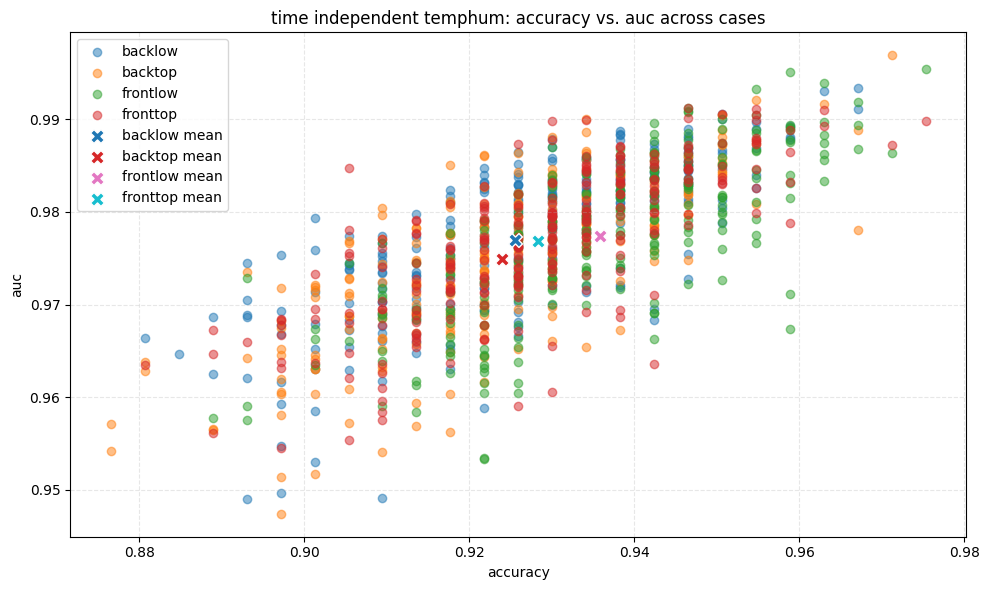

In [93]:
# plot metrics
metrics_plot = ["accuracy", "auc"]

colors = plt.cm.tab10(np.linspace(0, 1, len(case_order)))
case_color_map = {case: color for case, color in zip(case_order, colors)}
plt.figure(figsize=(10, 6))

for case in case_order:
    subset = df_metrics[df_metrics['case'] == case]
    plt.scatter(subset[metrics_plot[0]], subset[metrics_plot[1]], alpha=0.5, label=case)

# average
for case in case_order:
    subset = df_metrics[df_metrics['case'] == case]
    mean_x = subset[metrics_plot[0]].mean()
    mean_y = subset[metrics_plot[1]].mean()
    plt.scatter(mean_x, mean_y, marker='X', color=case_color_map[case], edgecolor='white', s=100, label=f'{case} mean')

plt.xlabel(f"{metrics_plot[0]}")
plt.ylabel(f"{metrics_plot[1]}")
plt.title(f"{model}: {metrics_plot[0]} vs. {metrics_plot[1]} across cases")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

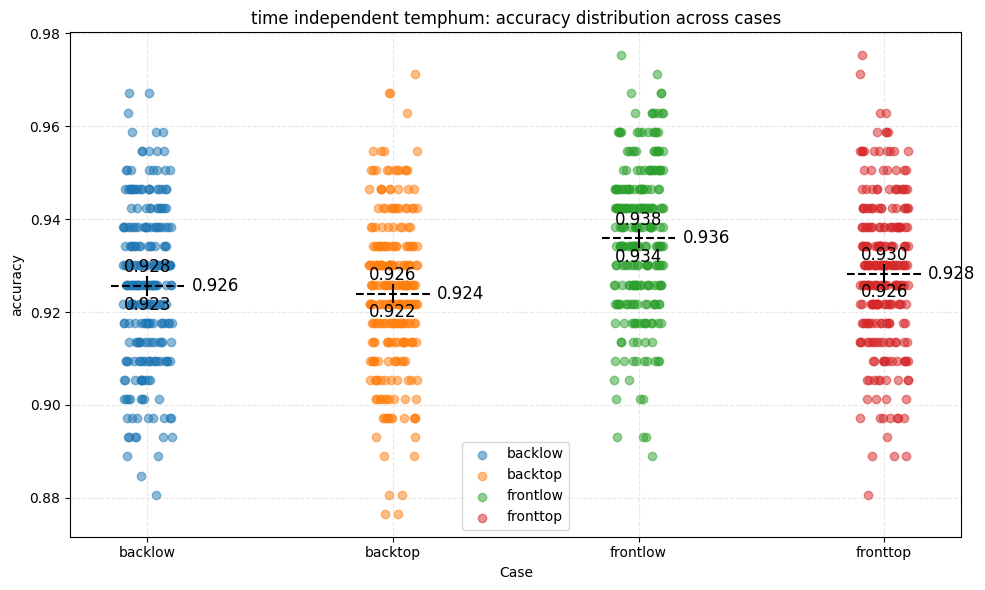

In [94]:
# plot accuracy
metric = "accuracy"

plt.figure(figsize=(10, 6))
for case in case_order:
    subset = df_metrics[df_metrics['case'] == case]
    plt.scatter(subset['x_jitter'], subset[metric], alpha=0.5, label=case)

for i, case in enumerate(case_order):
    vals = df_metrics[df_metrics['case'] == case][metric].values
    n = len(vals)
    mean_val = np.mean(vals)
    sem = stats.sem(vals)                  # standard error
    ci_low, ci_high = stats.t.interval(
        0.95, n - 1, loc=mean_val, scale=sem
    )
    plt.hlines(mean_val, i - 0.15, i + 0.15, colors='black', linestyles='dashed')
    plt.text(i + 0.18, mean_val, f"{mean_val:.3f}", va="center", ha="left", fontsize=12, color="black")
    plt.vlines(i, ci_low, ci_high, colors='black', linewidth=1.5)
    plt.text(i, ci_low, f"{ci_low:.3f}", va="top", ha="center", fontsize=12, color="black")
    plt.text(i, ci_high, f"{ci_high:.3f}", va="bottom", ha="center", fontsize=12, color="black")

plt.xticks(range(len(case_order)), case_order)
plt.xlabel("Case")
plt.ylabel(metric)
plt.title(f"{model}: {metric} distribution across cases")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

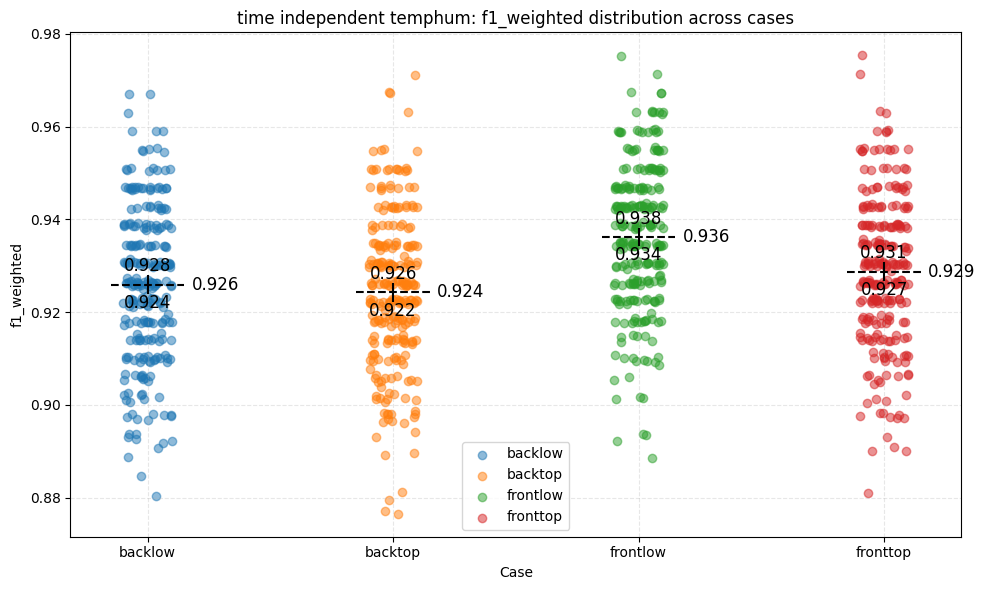

In [95]:
# plot f1 score
metric = "f1_weighted"

plt.figure(figsize=(10, 6))
for case in case_order:
    subset = df_metrics[df_metrics['case'] == case]
    plt.scatter(subset['x_jitter'], subset[metric], alpha=0.5, label=case)

for i, case in enumerate(case_order):
    vals = df_metrics[df_metrics['case'] == case][metric].values
    n = len(vals)
    mean_val = np.mean(vals)
    sem = stats.sem(vals)                  # standard error
    ci_low, ci_high = stats.t.interval(
        0.95, n - 1, loc=mean_val, scale=sem
    )
    plt.hlines(mean_val, i - 0.15, i + 0.15, colors='black', linestyles='dashed')
    plt.text(i + 0.18, mean_val, f"{mean_val:.3f}", va="center", ha="left", fontsize=12, color="black")
    plt.vlines(i, ci_low, ci_high, colors='black', linewidth=1.5)
    plt.text(i, ci_low, f"{ci_low:.3f}", va="top", ha="center", fontsize=12, color="black")
    plt.text(i, ci_high, f"{ci_high:.3f}", va="bottom", ha="center", fontsize=12, color="black")

plt.xticks(range(len(case_order)), case_order)
plt.xlabel("Case")
plt.ylabel(metric)
plt.title(f"{model}: {metric} distribution across cases")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

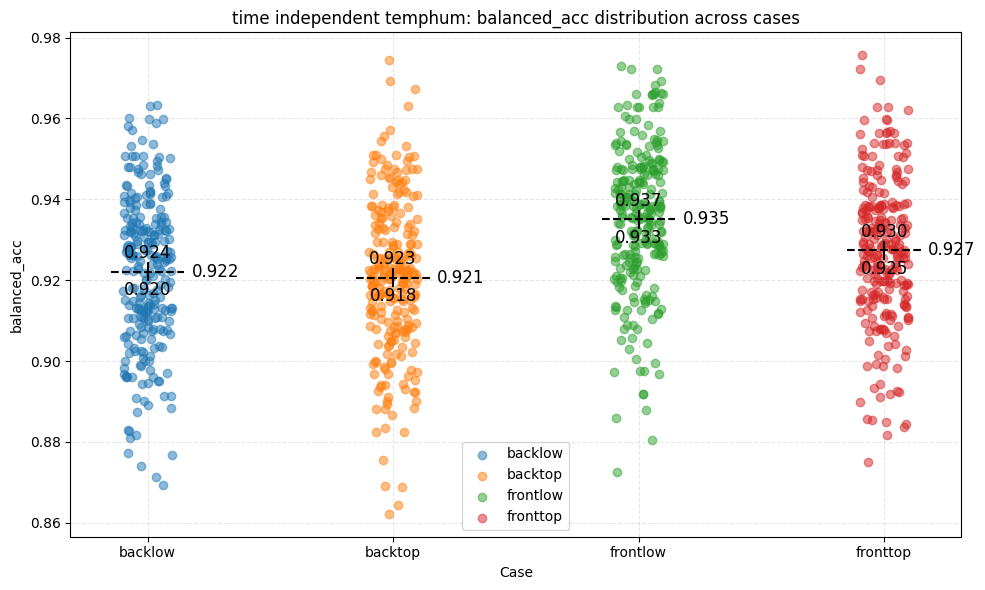

In [96]:
# plot balanced accuracy
metric = "balanced_acc"

plt.figure(figsize=(10, 6))
for case in case_order:
    subset = df_metrics[df_metrics['case'] == case]
    plt.scatter(subset['x_jitter'], subset[metric], alpha=0.5, label=case)

for i, case in enumerate(case_order):
    vals = df_metrics[df_metrics['case'] == case][metric].values
    n = len(vals)
    mean_val = np.mean(vals)
    sem = stats.sem(vals)                  # standard error
    ci_low, ci_high = stats.t.interval(
        0.95, n - 1, loc=mean_val, scale=sem
    )
    plt.hlines(mean_val, i - 0.15, i + 0.15, colors='black', linestyles='dashed')
    plt.text(i + 0.18, mean_val, f"{mean_val:.3f}", va="center", ha="left", fontsize=12, color="black")
    plt.vlines(i, ci_low, ci_high, colors='black', linewidth=1.5)
    plt.text(i, ci_low, f"{ci_low:.3f}", va="top", ha="center", fontsize=12, color="black")
    plt.text(i, ci_high, f"{ci_high:.3f}", va="bottom", ha="center", fontsize=12, color="black")

plt.xticks(range(len(case_order)), case_order)
plt.xlabel("Case")
plt.ylabel(metric)
plt.title(f"{model}: {metric} distribution across cases")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

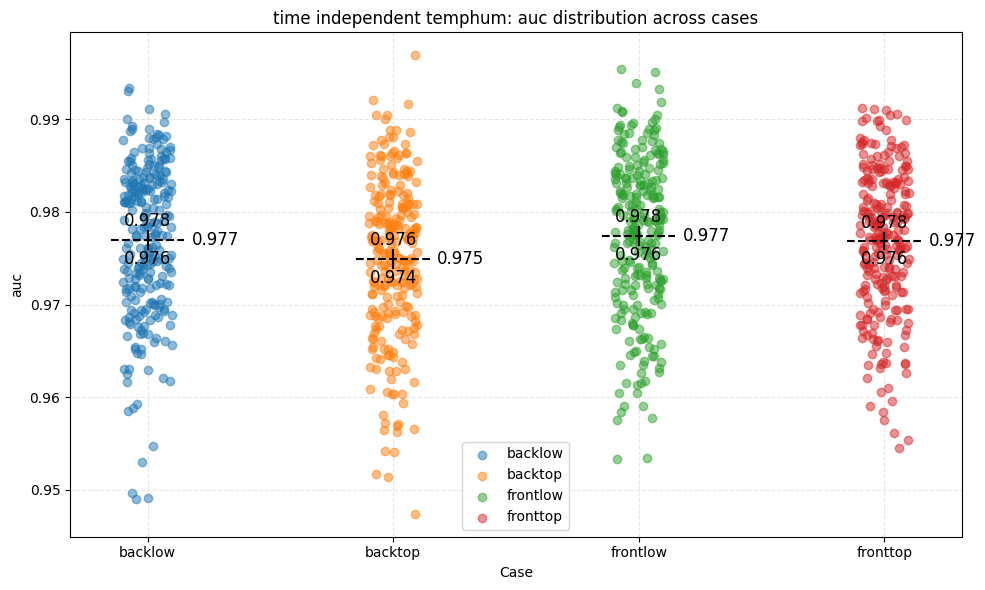

In [97]:
# plot auc
metric = "auc"

plt.figure(figsize=(10, 6))
for case in case_order:
    subset = df_metrics[df_metrics['case'] == case]
    plt.scatter(subset['x_jitter'], subset[metric], alpha=0.5, label=case)

for i, case in enumerate(case_order):
    vals = df_metrics[df_metrics['case'] == case][metric].values
    n = len(vals)
    mean_val = np.mean(vals)
    sem = stats.sem(vals)                  # standard error
    ci_low, ci_high = stats.t.interval(
        0.95, n - 1, loc=mean_val, scale=sem
    )
    plt.hlines(mean_val, i - 0.15, i + 0.15, colors='black', linestyles='dashed')
    plt.text(i + 0.18, mean_val, f"{mean_val:.3f}", va="center", ha="left", fontsize=12, color="black")
    plt.vlines(i, ci_low, ci_high, colors='black', linewidth=1.5)
    plt.text(i, ci_low, f"{ci_low:.3f}", va="top", ha="center", fontsize=12, color="black")
    plt.text(i, ci_high, f"{ci_high:.3f}", va="bottom", ha="center", fontsize=12, color="black")

plt.xticks(range(len(case_order)), case_order)
plt.xlabel("Case")
plt.ylabel(metric)
plt.title(f"{model}: {metric} distribution across cases")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

In [98]:
print(model)
check_anova_assumptions(
    df=df_metrics,
    group_col='case',
    metric_col='accuracy',
    group_order=case_order
)

time independent temphum

=== Normality test (D’Agostino and Pearson) for accuracy ===
backlow                  :	p = 0.3523	→	OK normal
backtop                  :	p = 0.6515	→	OK normal
frontlow                 :	p = 0.2214	→	OK normal
fronttop                 :	p = 0.7613	→	OK normal

=== Normality test (Shapiro-Wilk) for accuracy ===
backlow                  :	p = 0.0841	→	OK normal
backtop                  :	p = 0.0790	→	OK normal
frontlow                 :	p = 0.0319	→	not normal
fronttop                 :	p = 0.2120	→	OK normal

=== Normality test (Anderson-Darling) for accuracy ===
backlow                  :	A² = 0.9245,	5% critical = 0.7750	→	not normal
backtop                  :	A² = 0.9765,	5% critical = 0.7750	→	not normal
frontlow                 :	A² = 1.0091,	5% critical = 0.7750	→	not normal
fronttop                 :	A² = 0.8616,	5% critical = 0.7750	→	not normal

=== Homogeneity of variance tests for accuracy ===
Levene’s test  : p = 0.8598	→	OK equal variances
Bartlet

In [99]:
print(model)
check_anova_assumptions(
    df=df_metrics,
    group_col='case',
    metric_col='f1_weighted',
    group_order=case_order
)

time independent temphum

=== Normality test (D’Agostino and Pearson) for f1_weighted ===
backlow                  :	p = 0.3937	→	OK normal
backtop                  :	p = 0.5799	→	OK normal
frontlow                 :	p = 0.1719	→	OK normal
fronttop                 :	p = 0.7368	→	OK normal

=== Normality test (Shapiro-Wilk) for f1_weighted ===
backlow                  :	p = 0.3006	→	OK normal
backtop                  :	p = 0.2472	→	OK normal
frontlow                 :	p = 0.0848	→	OK normal
fronttop                 :	p = 0.5786	→	OK normal

=== Normality test (Anderson-Darling) for f1_weighted ===
backlow                  :	A² = 0.5521,	5% critical = 0.7750	→	OK normal
backtop                  :	A² = 0.6159,	5% critical = 0.7750	→	OK normal
frontlow                 :	A² = 0.6831,	5% critical = 0.7750	→	OK normal
fronttop                 :	A² = 0.5148,	5% critical = 0.7750	→	OK normal

=== Homogeneity of variance tests for f1_weighted ===
Levene’s test  : p = 0.8193	→	OK equal variances


In [100]:
print(model)
check_anova_assumptions(
    df=df_metrics,
    group_col='case',
    metric_col='balanced_acc',
    group_order=case_order
)

time independent temphum

=== Normality test (D’Agostino and Pearson) for balanced_acc ===
backlow                  :	p = 0.1985	→	OK normal
backtop                  :	p = 0.2525	→	OK normal
frontlow                 :	p = 0.0054	→	not normal
fronttop                 :	p = 0.4407	→	OK normal

=== Normality test (Shapiro-Wilk) for balanced_acc ===
backlow                  :	p = 0.1181	→	OK normal
backtop                  :	p = 0.1625	→	OK normal
frontlow                 :	p = 0.0084	→	not normal
fronttop                 :	p = 0.4094	→	OK normal

=== Normality test (Anderson-Darling) for balanced_acc ===
backlow                  :	A² = 0.5517,	5% critical = 0.7750	→	OK normal
backtop                  :	A² = 0.7130,	5% critical = 0.7750	→	OK normal
frontlow                 :	A² = 0.7577,	5% critical = 0.7750	→	OK normal
fronttop                 :	A² = 0.3930,	5% critical = 0.7750	→	OK normal

=== Homogeneity of variance tests for balanced_acc ===
Levene’s test  : p = 0.4829	→	OK equal vari

In [101]:
print(model)
check_anova_assumptions(
    df=df_metrics,
    group_col='case',
    metric_col='auc',
    group_order=case_order
)

time independent temphum

=== Normality test (D’Agostino and Pearson) for auc ===
backlow                  :	p = 0.0000	→	not normal
backtop                  :	p = 0.0155	→	not normal
frontlow                 :	p = 0.0156	→	not normal
fronttop                 :	p = 0.0149	→	not normal

=== Normality test (Shapiro-Wilk) for auc ===
backlow                  :	p = 0.0000	→	not normal
backtop                  :	p = 0.0159	→	not normal
frontlow                 :	p = 0.0029	→	not normal
fronttop                 :	p = 0.0014	→	not normal

=== Normality test (Anderson-Darling) for auc ===
backlow                  :	A² = 2.1699,	5% critical = 0.7750	→	not normal
backtop                  :	A² = 0.9110,	5% critical = 0.7750	→	not normal
frontlow                 :	A² = 1.2711,	5% critical = 0.7750	→	not normal
fronttop                 :	A² = 1.0776,	5% critical = 0.7750	→	not normal

=== Homogeneity of variance tests for auc ===
Levene’s test  : p = 0.5214	→	OK equal variances
Bartlett’s test: p =

### ANOVA

In [102]:
print(model)
run_anova_full(
    df=df_metrics,
    group_col='case',
    metric_col='accuracy'
)

time independent temphum

=== Welch ANOVA for accuracy ===
Source  ddof1      ddof2         F        p-unc      np2
  case      3 553.199006 26.797769 3.399098e-16 0.072889

Effect size (partial η², np2) = 0.0729 → medium effect

=== Games-Howell post-hoc test for accuracy ===
       A        B  mean(A)  mean(B)      diff       se         T         df         pval    hedges
 backlow  backtop 0.925580 0.923918  0.001663 0.001495  1.111926 497.947011 6.823523e-01  0.099304
 backlow frontlow 0.925580 0.935868 -0.010288 0.001461 -7.042740 496.304278 3.783995e-11 -0.628973
 backlow fronttop 0.925580 0.928263 -0.002683 0.001474 -1.820730 497.201541 2.647371e-01 -0.162606
 backtop frontlow 0.923918 0.935868 -0.011951 0.001453 -8.225415 496.847342 1.902922e-13 -0.734595
 backtop fronttop 0.923918 0.928263 -0.004346 0.001466 -2.964697 497.559028 1.670540e-02 -0.264771
frontlow fronttop 0.935868 0.928263  0.007605 0.001431  5.315510 497.831053 9.607781e-07  0.474717

=== Pairwise effect sizes fo

In [103]:
print(model)
run_anova_full(
    df=df_metrics,
    group_col='case',
    metric_col='f1_weighted'
)

time independent temphum

=== Welch ANOVA for f1_weighted ===
Source  ddof1      ddof2         F        p-unc      np2
  case      3 553.186529 27.160978 2.125487e-16 0.073924

Effect size (partial η², np2) = 0.0739 → medium effect

=== Games-Howell post-hoc test for f1_weighted ===
       A        B  mean(A)  mean(B)      diff       se         T         df         pval    hedges
 backlow  backtop 0.925917 0.924276  0.001641 0.001489  1.101818 497.954868 6.885816e-01  0.098401
 backlow frontlow 0.925917 0.936242 -0.010326 0.001453 -7.104031 496.248942 2.559286e-11 -0.634446
 backlow fronttop 0.925917 0.928734 -0.002817 0.001464 -1.924159 497.025480 2.191928e-01 -0.171843
 backtop frontlow 0.924276 0.936242 -0.011966 0.001446 -8.274178 496.762566 4.163336e-13 -0.738950
 backtop fronttop 0.924276 0.928734 -0.004457 0.001457 -3.059890 497.398521 1.245386e-02 -0.273272
frontlow fronttop 0.936242 0.928734  0.007509 0.001420  5.286083 497.885544 1.118841e-06  0.472089

=== Pairwise effect si

In [104]:
print(model)
run_anova_full(
    df=df_metrics,
    group_col='case',
    metric_col='balanced_acc'
)

time independent temphum

=== Welch ANOVA for balanced_acc ===
Source  ddof1      ddof2         F        p-unc      np2
  case      3 553.147114 31.262289 1.113754e-18 0.085248

Effect size (partial η², np2) = 0.0852 → medium effect

=== Games-Howell post-hoc test for balanced_acc ===
       A        B  mean(A)  mean(B)      diff       se         T         df         pval    hedges
 backlow  backtop 0.922119 0.920624  0.001495 0.001699  0.879930 497.999065 8.152842e-01  0.078585
 backlow frontlow 0.922119 0.935029 -0.012909 0.001654 -7.806797 496.534785 4.138911e-13 -0.697209
 backlow fronttop 0.922119 0.927354 -0.005235 0.001654 -3.165781 496.531329 8.886402e-03 -0.282729
 backtop frontlow 0.920624 0.935029 -0.014404 0.001655 -8.704635 496.460386 1.538769e-13 -0.777393
 backtop fronttop 0.920624 0.927354 -0.006730 0.001655 -4.067000 496.456845 3.221057e-04 -0.363215
frontlow fronttop 0.935029 0.927354  0.007674 0.001608  4.772703 497.999998 1.420245e-05  0.426240

=== Pairwise effect 

In [105]:
print(model)
run_anova_full(
    df=df_metrics,
    group_col='case',
    metric_col='auc'
)

time independent temphum

=== Welch ANOVA for auc ===
Source  ddof1      ddof2        F    p-unc      np2
  case      3 552.976946 4.168182 0.006199 0.013135

Effect size (partial η², np2) = 0.0131 → small effect

=== Games-Howell post-hoc test for auc ===
       A        B  mean(A)  mean(B)      diff       se         T         df     pval    hedges
 backlow  backtop 0.976960 0.974933  0.002027 0.000753  2.691806 497.344922 0.036797  0.240400
 backlow frontlow 0.976960 0.977424 -0.000463 0.000749 -0.618844 497.691388 0.926048 -0.055268
 backlow fronttop 0.976960 0.976850  0.000110 0.000718  0.153796 496.239663 0.998703  0.013735
 backtop frontlow 0.974933 0.977424 -0.002490 0.000762 -3.267067 497.935274 0.006365 -0.291775
 backtop fronttop 0.974933 0.976850 -0.001917 0.000732 -2.617003 493.485567 0.045072 -0.233719
frontlow fronttop 0.977424 0.976850  0.000574 0.000728  0.788291 494.482949 0.859776  0.070401

=== Pairwise effect sizes for auc (Hedges' g) ===
backlow    vs backtop   : g

## Time series - temphum

In [106]:
model = "time series temphum"
backlow = pd.read_csv("../_timeseries_results_raw/case_room1_backlow_state_timeseries_temphum.csv")
backtop = pd.read_csv("../_timeseries_results_raw/case_room1_backtop_state_timeseries_temphum.csv")
frontlow = pd.read_csv("../_timeseries_results_raw/case_room1_frontlow_state_timeseries_temphum.csv")
fronttop = pd.read_csv("../_timeseries_results_raw/case_room1_fronttop_state_timeseries_temphum.csv")

In [107]:
backlow.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
random_seed,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
accuracy,250.0,0.761644,0.036401,0.639269,0.739726,0.762557,0.788813,0.867580
f1,250.0,0.656790,0.064480,0.503704,0.616272,0.662252,0.705128,0.843243
balanced_acc,250.0,0.732486,0.041019,0.627011,0.707474,0.733867,0.762667,0.864858
auc,250.0,0.812717,0.068433,0.657737,0.769492,0.811794,0.864901,0.939319
feature_importance.backlow_temperature_scaled,250.0,0.069311,0.083533,-0.017808,0.011416,0.043607,0.082991,0.361187
feature_importance.backlow_temperature_fd1_scaled,250.0,-0.011425,0.027929,-0.098630,-0.027854,-0.010046,0.003196,0.106849
feature_importance.backlow_temperature_fd2_scaled,250.0,-0.015379,0.030729,-0.094521,-0.033676,-0.014840,0.002283,0.134247
feature_importance.backlow_temperature_fd3_scaled,250.0,-0.019151,0.030945,-0.105936,-0.041667,-0.015068,0.002283,0.085845


In [108]:
backtop.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
random_seed,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
accuracy,250.0,0.860800,0.025203,0.750000,0.858333,0.866667,0.875000,0.900000
f1,250.0,0.800051,0.050761,0.552239,0.797636,0.813953,0.827586,0.865169
balanced_acc,250.0,0.837444,0.034755,0.684195,0.833909,0.846651,0.857521,0.888073
auc,250.0,0.875042,0.017949,0.830567,0.865654,0.873090,0.878415,0.961222
feature_importance.backtop_temperature_scaled,250.0,0.090468,0.041600,0.004167,0.055000,0.088333,0.116562,0.232083
feature_importance.backtop_temperature_fd1_scaled,250.0,0.013233,0.015176,-0.017917,0.003333,0.011250,0.021562,0.080000
feature_importance.backtop_temperature_fd2_scaled,250.0,0.011167,0.016428,-0.022917,-0.000417,0.008750,0.019583,0.069583
feature_importance.backtop_temperature_fd3_scaled,250.0,0.008828,0.015897,-0.025833,-0.003333,0.007083,0.019583,0.053333


In [109]:
frontlow.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
random_seed,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
accuracy,250.0,0.776749,0.040346,0.630137,0.759132,0.785388,0.803653,0.872146
f1,250.0,0.684697,0.063291,0.444444,0.653061,0.692810,0.729560,0.837209
balanced_acc,250.0,0.749973,0.042582,0.628552,0.729374,0.756547,0.779784,0.859808
auc,250.0,0.855011,0.042985,0.727063,0.825188,0.857626,0.887795,0.947278
feature_importance.frontlow_temperature_scaled,250.0,0.049936,0.069972,-0.018265,0.005137,0.016667,0.075799,0.272146
feature_importance.frontlow_temperature_fd1_scaled,250.0,0.011195,0.029398,-0.103653,-0.007648,0.008219,0.028767,0.123288
feature_importance.frontlow_temperature_fd2_scaled,250.0,0.006389,0.029098,-0.063014,-0.010046,0.002968,0.019635,0.182648
feature_importance.frontlow_temperature_fd3_scaled,250.0,-0.002347,0.028855,-0.114612,-0.019178,-0.004566,0.011758,0.118721


In [110]:
fronttop.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
random_seed,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
accuracy,250.0,0.821281,0.042122,0.614719,0.818182,0.831169,0.839827,0.874459
f1,250.0,0.750985,0.048151,0.562963,0.737500,0.760736,0.778443,0.834286
balanced_acc,250.0,0.796447,0.039141,0.621051,0.788278,0.804582,0.817290,0.860768
auc,250.0,0.829330,0.067195,0.695183,0.773342,0.817524,0.882957,0.958789
feature_importance.fronttop_temperature_scaled,250.0,0.113607,0.107939,-0.003030,0.042965,0.064935,0.158442,0.434199
feature_importance.fronttop_temperature_fd1_scaled,250.0,0.014803,0.027518,-0.048052,0.000108,0.009957,0.024134,0.177489
feature_importance.fronttop_temperature_fd2_scaled,250.0,0.009882,0.023955,-0.045022,-0.002165,0.004762,0.017641,0.131169
feature_importance.fronttop_temperature_fd3_scaled,250.0,0.007326,0.025721,-0.084848,-0.004329,0.003463,0.014069,0.136797


In [111]:
backlow['case'] = 'backlow'
backtop['case'] = 'backtop'
frontlow['case'] = 'frontlow'
fronttop['case'] = 'fronttop'

metrics = ["case", "accuracy", "f1", "balanced_acc", "auc"]

df_metrics = pd.concat(
    [
        backlow[metrics],
        backtop[metrics],
        frontlow[metrics],
        fronttop[metrics]
    ],
    ignore_index=True
)

df_metrics.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   case          1000 non-null   object 
 1   accuracy      1000 non-null   float64
 2   f1            1000 non-null   float64
 3   balanced_acc  1000 non-null   float64
 4   auc           1000 non-null   float64
dtypes: float64(4), object(1)
memory usage: 39.2+ KB


In [112]:
case_order = ['backlow', 'backtop', 'frontlow', 'fronttop']
df_metrics['x'] = df_metrics['case'].map({name: i for i, name in enumerate(case_order)})
df_metrics['x_jitter'] = df_metrics['x'] + np.random.uniform(-0.1, 0.1, size=len(df_metrics))

df_metrics.head().T

,0,1,2,3,4
case,backlow,backlow,backlow,backlow,backlow
accuracy,0.753425,0.739726,0.762557,0.826484,0.694064
f1,0.635135,0.606897,0.662338,0.768293,0.503704
balanced_acc,0.720002,0.703697,0.733867,0.806958,0.64935
auc,0.698904,0.885741,0.791938,0.81633,0.835673
x,0,0,0,0,0
x_jitter,0.088823,-0.020131,0.006965,-0.007369,-0.084344


### plot

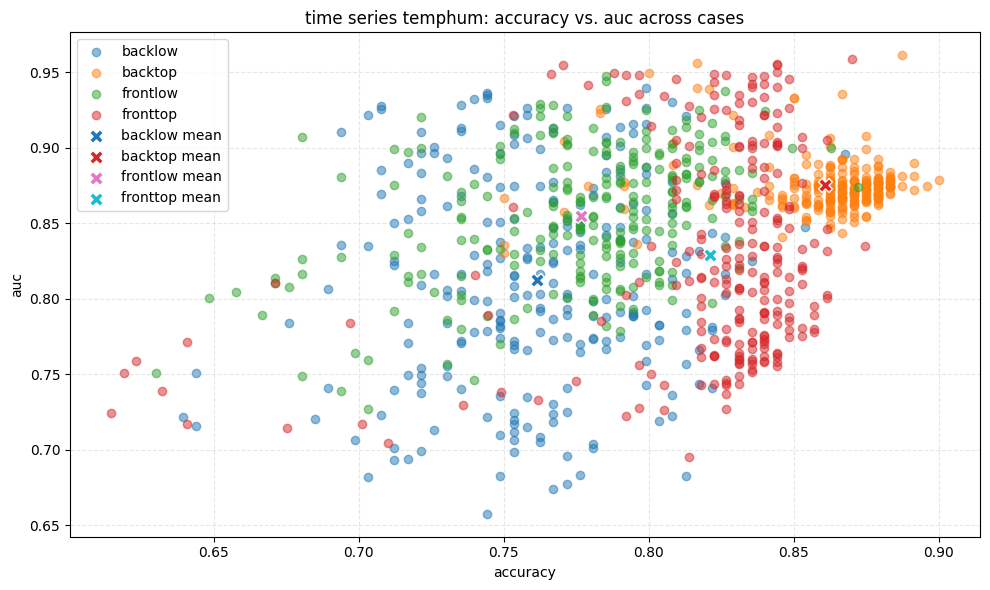

In [113]:
# plot metrics
metrics_plot = ["accuracy", "auc"]

colors = plt.cm.tab10(np.linspace(0, 1, len(case_order)))
case_color_map = {case: color for case, color in zip(case_order, colors)}
plt.figure(figsize=(10, 6))

for case in case_order:
    subset = df_metrics[df_metrics['case'] == case]
    plt.scatter(subset[metrics_plot[0]], subset[metrics_plot[1]], alpha=0.5, label=case)

# average
for case in case_order:
    subset = df_metrics[df_metrics['case'] == case]
    mean_x = subset[metrics_plot[0]].mean()
    mean_y = subset[metrics_plot[1]].mean()
    plt.scatter(mean_x, mean_y, marker='X', color=case_color_map[case], edgecolor='white', s=100, label=f'{case} mean')

plt.xlabel(f"{metrics_plot[0]}")
plt.ylabel(f"{metrics_plot[1]}")
plt.title(f"{model}: {metrics_plot[0]} vs. {metrics_plot[1]} across cases")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

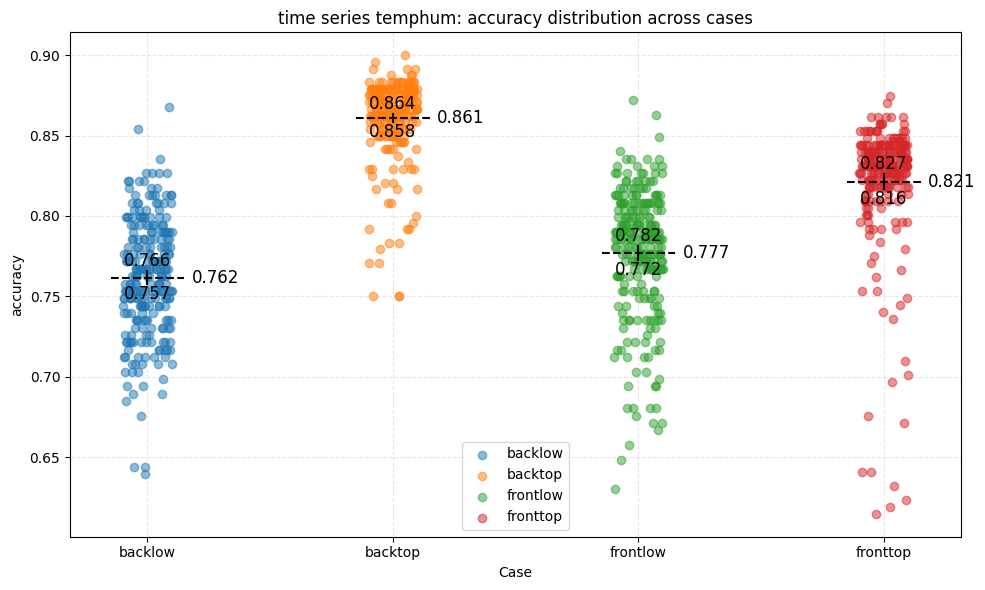

In [114]:
# plot accuracy
metric = "accuracy"

plt.figure(figsize=(10, 6))
for case in case_order:
    subset = df_metrics[df_metrics['case'] == case]
    plt.scatter(subset['x_jitter'], subset[metric], alpha=0.5, label=case)

for i, case in enumerate(case_order):
    vals = df_metrics[df_metrics['case'] == case][metric].values
    n = len(vals)
    mean_val = np.mean(vals)
    sem = stats.sem(vals)                  # standard error
    ci_low, ci_high = stats.t.interval(
        0.95, n - 1, loc=mean_val, scale=sem
    )
    plt.hlines(mean_val, i - 0.15, i + 0.15, colors='black', linestyles='dashed')
    plt.text(i + 0.18, mean_val, f"{mean_val:.3f}", va="center", ha="left", fontsize=12, color="black")
    plt.vlines(i, ci_low, ci_high, colors='black', linewidth=1.5)
    plt.text(i, ci_low, f"{ci_low:.3f}", va="top", ha="center", fontsize=12, color="black")
    plt.text(i, ci_high, f"{ci_high:.3f}", va="bottom", ha="center", fontsize=12, color="black")

plt.xticks(range(len(case_order)), case_order)
plt.xlabel("Case")
plt.ylabel(metric)
plt.title(f"{model}: {metric} distribution across cases")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

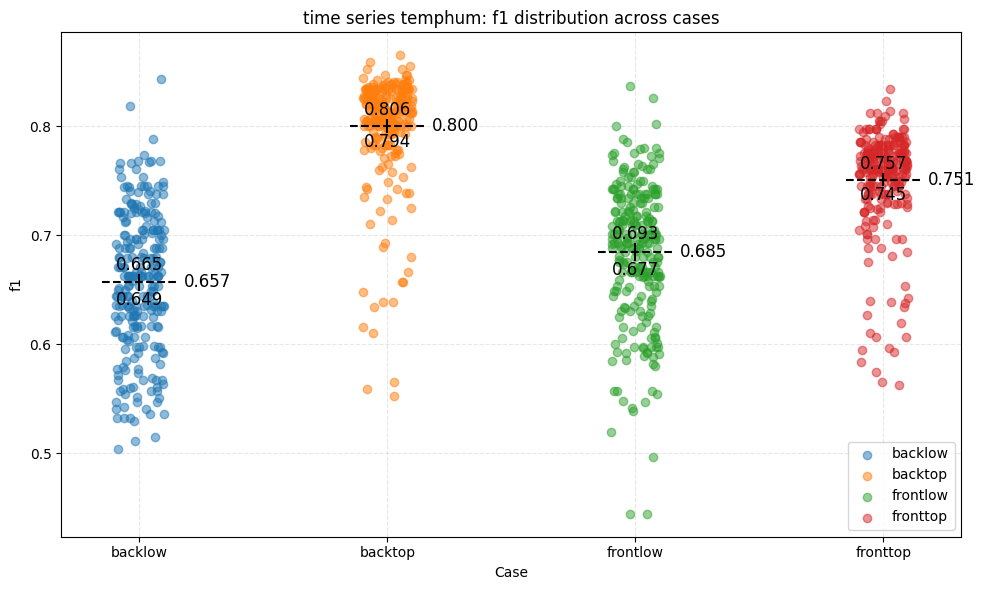

In [115]:
# plot f1 score
metric = "f1"

plt.figure(figsize=(10, 6))
for case in case_order:
    subset = df_metrics[df_metrics['case'] == case]
    plt.scatter(subset['x_jitter'], subset[metric], alpha=0.5, label=case)

for i, case in enumerate(case_order):
    vals = df_metrics[df_metrics['case'] == case][metric].values
    n = len(vals)
    mean_val = np.mean(vals)
    sem = stats.sem(vals)                  # standard error
    ci_low, ci_high = stats.t.interval(
        0.95, n - 1, loc=mean_val, scale=sem
    )
    plt.hlines(mean_val, i - 0.15, i + 0.15, colors='black', linestyles='dashed')
    plt.text(i + 0.18, mean_val, f"{mean_val:.3f}", va="center", ha="left", fontsize=12, color="black")
    plt.vlines(i, ci_low, ci_high, colors='black', linewidth=1.5)
    plt.text(i, ci_low, f"{ci_low:.3f}", va="top", ha="center", fontsize=12, color="black")
    plt.text(i, ci_high, f"{ci_high:.3f}", va="bottom", ha="center", fontsize=12, color="black")

plt.xticks(range(len(case_order)), case_order)
plt.xlabel("Case")
plt.ylabel(metric)
plt.title(f"{model}: {metric} distribution across cases")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

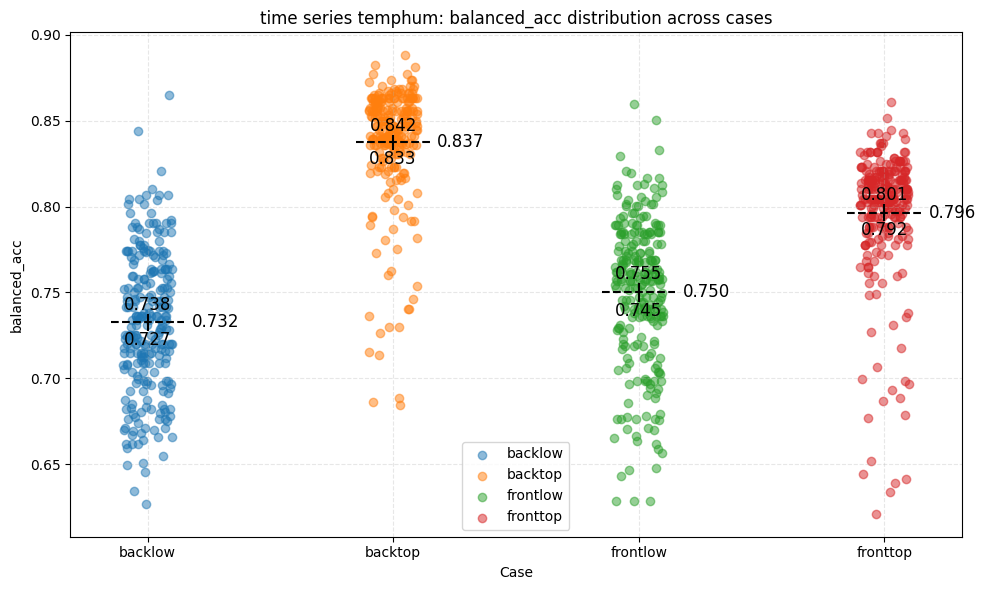

In [116]:
# plot balanced accuracy
metric = "balanced_acc"

plt.figure(figsize=(10, 6))
for case in case_order:
    subset = df_metrics[df_metrics['case'] == case]
    plt.scatter(subset['x_jitter'], subset[metric], alpha=0.5, label=case)

for i, case in enumerate(case_order):
    vals = df_metrics[df_metrics['case'] == case][metric].values
    n = len(vals)
    mean_val = np.mean(vals)
    sem = stats.sem(vals)                  # standard error
    ci_low, ci_high = stats.t.interval(
        0.95, n - 1, loc=mean_val, scale=sem
    )
    plt.hlines(mean_val, i - 0.15, i + 0.15, colors='black', linestyles='dashed')
    plt.text(i + 0.18, mean_val, f"{mean_val:.3f}", va="center", ha="left", fontsize=12, color="black")
    plt.vlines(i, ci_low, ci_high, colors='black', linewidth=1.5)
    plt.text(i, ci_low, f"{ci_low:.3f}", va="top", ha="center", fontsize=12, color="black")
    plt.text(i, ci_high, f"{ci_high:.3f}", va="bottom", ha="center", fontsize=12, color="black")

plt.xticks(range(len(case_order)), case_order)
plt.xlabel("Case")
plt.ylabel(metric)
plt.title(f"{model}: {metric} distribution across cases")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

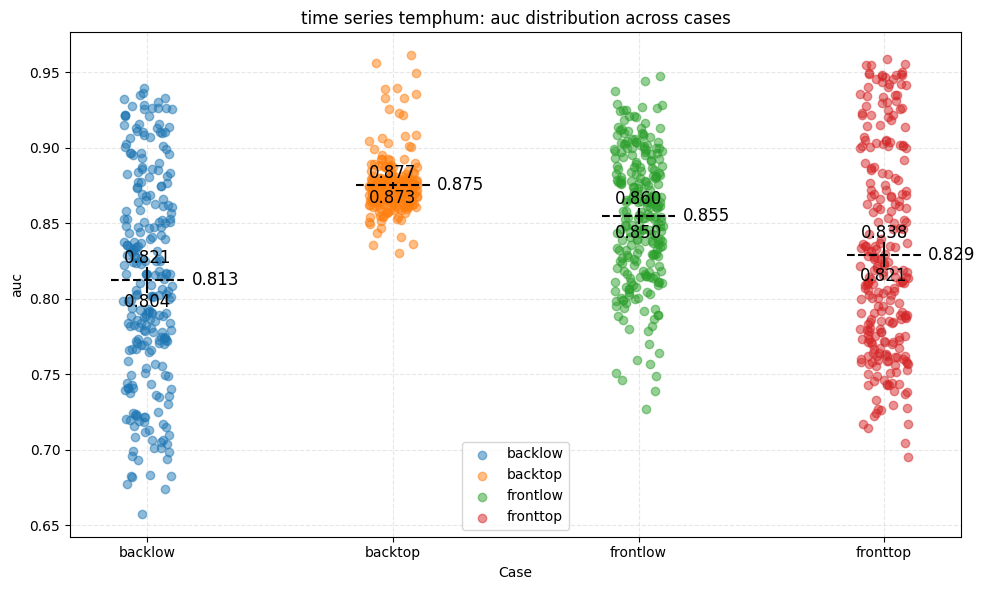

In [117]:
# plot auc
metric = "auc"

plt.figure(figsize=(10, 6))
for case in case_order:
    subset = df_metrics[df_metrics['case'] == case]
    plt.scatter(subset['x_jitter'], subset[metric], alpha=0.5, label=case)

for i, case in enumerate(case_order):
    vals = df_metrics[df_metrics['case'] == case][metric].values
    n = len(vals)
    mean_val = np.mean(vals)
    sem = stats.sem(vals)                  # standard error
    ci_low, ci_high = stats.t.interval(
        0.95, n - 1, loc=mean_val, scale=sem
    )
    plt.hlines(mean_val, i - 0.15, i + 0.15, colors='black', linestyles='dashed')
    plt.text(i + 0.18, mean_val, f"{mean_val:.3f}", va="center", ha="left", fontsize=12, color="black")
    plt.vlines(i, ci_low, ci_high, colors='black', linewidth=1.5)
    plt.text(i, ci_low, f"{ci_low:.3f}", va="top", ha="center", fontsize=12, color="black")
    plt.text(i, ci_high, f"{ci_high:.3f}", va="bottom", ha="center", fontsize=12, color="black")

plt.xticks(range(len(case_order)), case_order)
plt.xlabel("Case")
plt.ylabel(metric)
plt.title(f"{model}: {metric} distribution across cases")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

In [118]:
print(model)
check_anova_assumptions(
    df=df_metrics,
    group_col='case',
    metric_col='accuracy',
    group_order=case_order
)

time series temphum

=== Normality test (D’Agostino and Pearson) for accuracy ===
backlow                  :	p = 0.0432	→	not normal
backtop                  :	p = 0.0000	→	not normal
frontlow                 :	p = 0.0000	→	not normal
fronttop                 :	p = 0.0000	→	not normal

=== Normality test (Shapiro-Wilk) for accuracy ===
backlow                  :	p = 0.0477	→	not normal
backtop                  :	p = 0.0000	→	not normal
frontlow                 :	p = 0.0000	→	not normal
fronttop                 :	p = 0.0000	→	not normal

=== Normality test (Anderson-Darling) for accuracy ===
backlow                  :	A² = 0.5203,	5% critical = 0.7750	→	OK normal
backtop                  :	A² = 17.0087,	5% critical = 0.7750	→	not normal
frontlow                 :	A² = 4.6218,	5% critical = 0.7750	→	not normal
fronttop                 :	A² = 27.3535,	5% critical = 0.7750	→	not normal

=== Homogeneity of variance tests for accuracy ===
Levene’s test  : p = 0.0000	→	unequal variances
Bartl

In [119]:
print(model)
check_anova_assumptions(
    df=df_metrics,
    group_col='case',
    metric_col='f1',
    group_order=case_order
)

time series temphum

=== Normality test (D’Agostino and Pearson) for f1 ===
backlow                  :	p = 0.1910	→	OK normal
backtop                  :	p = 0.0000	→	not normal
frontlow                 :	p = 0.0000	→	not normal
fronttop                 :	p = 0.0000	→	not normal

=== Normality test (Shapiro-Wilk) for f1 ===
backlow                  :	p = 0.0938	→	OK normal
backtop                  :	p = 0.0000	→	not normal
frontlow                 :	p = 0.0000	→	not normal
fronttop                 :	p = 0.0000	→	not normal

=== Normality test (Anderson-Darling) for f1 ===
backlow                  :	A² = 0.6413,	5% critical = 0.7750	→	OK normal
backtop                  :	A² = 22.0405,	5% critical = 0.7750	→	not normal
frontlow                 :	A² = 2.3374,	5% critical = 0.7750	→	not normal
fronttop                 :	A² = 14.8243,	5% critical = 0.7750	→	not normal

=== Homogeneity of variance tests for f1 ===
Levene’s test  : p = 0.0000	→	unequal variances
Bartlett’s test: p = 0.0000	→	u

In [120]:
print(model)
check_anova_assumptions(
    df=df_metrics,
    group_col='case',
    metric_col='balanced_acc',
    group_order=case_order
)

time series temphum

=== Normality test (D’Agostino and Pearson) for balanced_acc ===
backlow                  :	p = 0.7697	→	OK normal
backtop                  :	p = 0.0000	→	not normal
frontlow                 :	p = 0.0015	→	not normal
fronttop                 :	p = 0.0000	→	not normal

=== Normality test (Shapiro-Wilk) for balanced_acc ===
backlow                  :	p = 0.4817	→	OK normal
backtop                  :	p = 0.0000	→	not normal
frontlow                 :	p = 0.0001	→	not normal
fronttop                 :	p = 0.0000	→	not normal

=== Normality test (Anderson-Darling) for balanced_acc ===
backlow                  :	A² = 0.3730,	5% critical = 0.7750	→	OK normal
backtop                  :	A² = 17.3394,	5% critical = 0.7750	→	not normal
frontlow                 :	A² = 2.4628,	5% critical = 0.7750	→	not normal
fronttop                 :	A² = 18.1507,	5% critical = 0.7750	→	not normal

=== Homogeneity of variance tests for balanced_acc ===
Levene’s test  : p = 0.0000	→	unequal v

In [121]:
print(model)
check_anova_assumptions(
    df=df_metrics,
    group_col='case',
    metric_col='auc',
    group_order=case_order
)

time series temphum

=== Normality test (D’Agostino and Pearson) for auc ===
backlow                  :	p = 0.0000	→	not normal
backtop                  :	p = 0.0000	→	not normal
frontlow                 :	p = 0.0530	→	OK normal
fronttop                 :	p = 0.0000	→	not normal

=== Normality test (Shapiro-Wilk) for auc ===
backlow                  :	p = 0.0005	→	not normal
backtop                  :	p = 0.0000	→	not normal
frontlow                 :	p = 0.0135	→	not normal
fronttop                 :	p = 0.0000	→	not normal

=== Normality test (Anderson-Darling) for auc ===
backlow                  :	A² = 1.0762,	5% critical = 0.7750	→	not normal
backtop                  :	A² = 12.5021,	5% critical = 0.7750	→	not normal
frontlow                 :	A² = 0.8328,	5% critical = 0.7750	→	not normal
fronttop                 :	A² = 3.6173,	5% critical = 0.7750	→	not normal

=== Homogeneity of variance tests for auc ===
Levene’s test  : p = 0.0000	→	unequal variances
Bartlett’s test: p = 0.000

### ANOVA

In [122]:
print(model)
run_anova_full(
    df=df_metrics,
    group_col='case',
    metric_col='accuracy'
)

time series temphum

=== Welch ANOVA for accuracy ===
Source  ddof1      ddof2          F         p-unc      np2
  case      3 540.282921 526.339974 7.192435e-160 0.531394

Effect size (partial η², np2) = 0.5314 → large effect

=== Games-Howell post-hoc test for accuracy ===
       A        B  mean(A)  mean(B)      diff       se          T         df         pval    hedges
 backlow  backtop 0.761644 0.860800 -0.099156 0.002800 -35.410698 443.122933 8.448797e-14 -3.162457
 backlow frontlow 0.761644 0.776749 -0.015105 0.003437  -4.395101 492.817989 7.986568e-05 -0.392517
 backlow fronttop 0.761644 0.821281 -0.059638 0.003521 -16.937750 487.751824 4.205525e-13 -1.512676
 backtop frontlow 0.860800 0.776749  0.084051 0.003009  27.936199 417.647591 2.581269e-13  2.494925
 backtop fronttop 0.860800 0.821281  0.039519 0.003105  12.729411 407.032030 2.305933e-13  1.136838
frontlow fronttop 0.776749 0.821281 -0.044533 0.003689 -12.071798 497.078815 2.907674e-13 -1.078108

=== Pairwise effect siz

In [123]:
print(model)
run_anova_full(
    df=df_metrics,
    group_col='case',
    metric_col='f1'
)

time series temphum

=== Welch ANOVA for f1 ===
Source  ddof1      ddof2          F         p-unc      np2
  case      3 549.336094 320.466352 3.157166e-120 0.491485

Effect size (partial η², np2) = 0.4915 → large effect

=== Games-Howell post-hoc test for f1 ===
       A        B  mean(A)  mean(B)      diff       se          T         df         pval    hedges
 backlow  backtop 0.656790 0.800051 -0.143261 0.005190 -27.602619 471.986098 1.237899e-13 -2.465133
 backlow frontlow 0.656790 0.684697 -0.027907 0.005714  -4.883627 497.827768 8.358946e-06 -0.436147
 backlow fronttop 0.656790 0.750985 -0.094195 0.005090 -18.507114 460.833695 3.319567e-14 -1.652832
 backtop frontlow 0.800051 0.684697  0.115354 0.005131  22.480588 475.581501 2.631229e-14  2.007695
 backtop fronttop 0.800051 0.750985  0.049066 0.004425  11.088320 496.618743 1.627587e-13  0.990275
frontlow fronttop 0.684697 0.750985 -0.066288 0.005030 -13.179495 464.907165 3.902434e-13 -1.177034

=== Pairwise effect sizes for f1 (H

In [124]:
print(model)
run_anova_full(
    df=df_metrics,
    group_col='case',
    metric_col='balanced_acc'
)

time series temphum

=== Welch ANOVA for balanced_acc ===
Source  ddof1      ddof2          F         p-unc      np2
  case      3 551.759583 388.904092 1.182101e-135 0.519922

Effect size (partial η², np2) = 0.5199 → large effect

=== Games-Howell post-hoc test for balanced_acc ===
       A        B  mean(A)  mean(B)      diff       se          T         df         pval    hedges
 backlow  backtop 0.732486 0.837444 -0.104958 0.003400 -30.867622 484.924762 3.742562e-13 -2.756724
 backlow frontlow 0.732486 0.749973 -0.017487 0.003739  -4.676457 497.305319 2.231387e-05 -0.417645
 backlow fronttop 0.732486 0.796447 -0.063961 0.003586 -17.837122 496.910890 0.000000e+00 -1.592997
 backtop frontlow 0.837444 0.749973  0.087471 0.003476  25.162375 478.781483 1.730838e-13  2.247200
 backtop fronttop 0.837444 0.796447  0.040997 0.003311  12.383642 491.126891 2.288170e-13  1.105958
frontlow fronttop 0.749973 0.796447 -0.046474 0.003658 -12.704834 494.507086 0.000000e+00 -1.134643

=== Pairwise ef

In [125]:
print(model)
run_anova_full(
    df=df_metrics,
    group_col='case',
    metric_col='auc'
)

time series temphum

=== Welch ANOVA for auc ===
Source  ddof1      ddof2         F        p-unc      np2
  case      3 478.474742 101.51058 7.319909e-51 0.167302

Effect size (partial η², np2) = 0.1673 → large effect

=== Games-Howell post-hoc test for auc ===
       A        B  mean(A)  mean(B)      diff       se          T         df         pval    hedges
 backlow  backtop 0.812717 0.875042 -0.062325 0.004474 -13.929043 283.096432 2.664535e-15 -1.243974
 backlow frontlow 0.812717 0.855011 -0.042294 0.005111  -8.275035 419.018173 3.252953e-13 -0.739026
 backlow fronttop 0.812717 0.829330 -0.016613 0.006066  -2.738790 497.834179 3.229886e-02 -0.244596
 backtop frontlow 0.875042 0.855011  0.020031 0.002946   6.799141 333.266482 2.923877e-10  0.607217
 backtop fronttop 0.875042 0.829330  0.045712 0.004399  10.392015 284.351519 0.000000e+00  0.928090
frontlow fronttop 0.855011 0.829330  0.025682 0.005045   5.090540 423.558499 3.206858e-06  0.454626

=== Pairwise effect sizes for auc (He